# A1 · CNN và Transformer trên toàn bộ GTSRB
**CO5085 · Học kỳ 261 · Notebook độc lập · Python 3.14 · CUDA**

**Restart Kernel → Run All** thực hiện kiểm tra dữ liệu/GPU, huấn luyện 14 model
trên full split, đánh giá checkpoint, rồi trình bày kết quả trong output cell.
Không xuất weights, CSV, PNG hoặc báo cáo riêng; checkpoint giữ trong CPU RAM.

| Yêu cầu đề A1 | Thực nghiệm trong notebook |
|---|---|
| Dataset công khai, khác tập ảnh nhỏ, ≥10 lớp | GTSRB: 43 lớp, 31.380 train / 7.829 validation / 12.630 official test |
| CNN và Transformer | ResNet-50 và DeiT-Small/16, tự định nghĩa bằng PyTorch |
| Scratch vs pretrained | Cả hai họ, cùng split/input/augmentation |
| Ba mức freeze pretrained | Head-only; partial; full fine-tune cho từng họ |
| Accuracy/F1, tham số trainable, thời gian, bộ nhớ, lỗi | Bảng validation/test, learning curves, VRAM, confusion matrix có số và ảnh lỗi |
| Tái lập | Seed/config/log RAM, ablation augmentation và ba seed |

A1.1: dữ liệu, nguồn/quyền sử dụng, split, augmentation và protocol.
A1.2: cấu hình chạy, bảng số liệu và đồ thị.

## 1. Môi trường, GPU và cấu hình

In [1]:
import copy
import csv
import hashlib
import importlib.metadata
import json
import math
import os
import random
import sys
import time
from datetime import datetime, timezone
from io import BytesIO
from pathlib import Path
from uuid import uuid4

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
from IPython.display import Markdown, display
from matplotlib.ticker import MaxNLocator
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

CPU_THREADS = min(12, os.cpu_count() or 1)
for variable in (
    "OMP_NUM_THREADS",
    "MKL_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ[variable] = str(CPU_THREADS)
torch.set_num_threads(CPU_THREADS)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

SESSION_STARTED = time.perf_counter()
EXECUTION_LOG = []


def log(stage, message, model=None, *, console=True):
    prefix = f"[{time.strftime('%H:%M:%S')}] [{stage}]"
    if model:
        prefix += f" [{model}]"
    line = f"{prefix} {message}"
    EXECUTION_LOG.append(line)
    if console:
        print(line, flush=True)


class TextProgress:
    """Update one plain-text display per model without clearing other outputs."""

    def __init__(self, model):
        self.model = model
        self.started = time.perf_counter()
        self.phase_started = self.started
        self.last_refresh = 0.0
        self.state = {
            "phase": "Chuẩn bị",
            "epoch": 0,
            "max_epochs": MAX_EPOCHS,
            "step": 0,
            "batches": 0,
            "samples": 0,
            "total_samples": 0,
            "loss": None,
            "accuracy": None,
            "updates": 0,
            "skips": 0,
            "vram": 0.0,
            "train_verified": False,
            "eval_verified": False,
            "validation": "Chưa đánh giá",
            "test": "Chưa đánh giá",
            "validation_macro_f1": None,
            "test_macro_f1": None,
            "checkpoint": "Chưa chọn",
            "bad": 0,
            "patience": EARLY_STOP_PATIENCE,
            "min_delta": EARLY_STOP_MIN_DELTA,
            "status": "Khởi tạo model",
            "batch_config": f"batch={BATCH_SIZE}; accumulation={ACCUMULATION_STEPS}",
        }
        self.gpu = torch.cuda.get_device_name(DEVICE)
        self.handle = display({"text/plain": self.render()}, raw=True, display_id=True)

    @staticmethod
    def bar(current, total, width=24):
        fraction = min(1.0, max(0.0, current / total)) if total else 0.0
        filled = int(width * fraction)
        return "[" + "#" * filled + "-" * (width - filled) + f"] {100 * fraction:5.1f}%"

    @staticmethod
    def duration(seconds):
        minutes, seconds = divmod(max(0, int(seconds)), 60)
        hours, minutes = divmod(minutes, 60)
        return f"{hours:02}:{minutes:02}:{seconds:02}"

    def start_phase(self, phase, batches, total_samples, **changes):
        self.phase_started = time.perf_counter()
        self.update(
            force=True,
            phase=phase,
            batches=batches,
            total_samples=total_samples,
            step=0,
            samples=0,
            loss=None,
            accuracy=None,
            **changes,
        )

    def update(self, *, force=False, **changes):
        self.state.update(changes)
        now = time.perf_counter()
        if not force and now - self.last_refresh < PROGRESS_REFRESH_SECONDS:
            return
        payload = {"text/plain": self.render()}
        if self.handle is not None:
            self.handle.update(payload, raw=True)
        self.last_refresh = now

    def render(self):
        s = self.state
        elapsed = time.perf_counter() - self.started
        phase_elapsed = time.perf_counter() - self.phase_started
        eta = (
            self.duration(phase_elapsed * (s["batches"] - s["step"]) / s["step"])
            if s["step"]
            else "--:--:--"
        )
        loss = f"{s['loss']:.4f}" if s["loss"] is not None else "----"
        accuracy = (
            f"{100 * s['accuracy']:.2f}%" if s["accuracy"] is not None else "----"
        )
        validation_f1 = (
            f"{s['validation_macro_f1']:.4f}"
            if s["validation_macro_f1"] is not None
            else "chưa đánh giá"
        )
        test_f1 = (
            f"{s['test_macro_f1']:.4f}"
            if s["test_macro_f1"] is not None
            else "chưa đánh giá"
        )
        train_proof = (
            "parameters/images/labels/logits/gradient: CUDA xác nhận"
            if s["train_verified"]
            else "train: chờ xác nhận tensor/gradient CUDA"
        )
        eval_proof = " | eval: CUDA xác nhận" if s["eval_verified"] else ""
        return "\n".join(
            [
                f"{self.model} | GPU: {self.gpu} | device={DEVICE} | AMP train",
                f"Batch: {s['batch_config']}",
                f"Epoch {s['epoch']}/{s['max_epochs']} (giới hạn; có early stopping)",
                f"{s['phase']} {self.bar(s['step'], s['batches'])} | batch {s['step']}/{s['batches']} | ảnh {s['samples']:,}/{s['total_samples']:,}",
                f"Loss={loss} | Accuracy={accuracy} | Updates train/epoch={s['updates']} | AMP skips train/epoch={s['skips']} | VRAM={s['vram']:.0f} MiB",
                f"Validation: {s['validation']} | Macro-F1={validation_f1}",
                f"Test: {s['test']} | Macro-F1={test_f1}",
                f"Checkpoint: {s['checkpoint']} | Early stop={s['bad']}/{s['patience']} | min_delta={s['min_delta']:g}",
                train_proof + eval_proof,
                f"Thời gian từ khi bắt đầu run={self.duration(elapsed)} | ETA pha hiện tại≈{eta} | {s['status']}",
            ]
        )

In [2]:
NAME = "A1"
DATA_SCOPE = "GTSRB đầy đủ"
SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 128
ACCUMULATION_STEPS = 1
EFFECTIVE_BATCH = BATCH_SIZE * ACCUMULATION_STEPS
INFERENCE_BENCHMARK_BATCH = 32
SCRATCH_EPOCHS = 40
PRETRAINED_EPOCHS = 25
MAX_EPOCHS = max(SCRATCH_EPOCHS, PRETRAINED_EPOCHS)
EARLY_STOP_PATIENCE = 4
EARLY_STOP_MIN_DELTA = 1e-4
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
WARMUP_EPOCHS = 3
PROGRESS_REFRESH_SECONDS = 0.25
NUM_WORKERS = 0
FAMILY_LABELS = {"resnet50": "ResNet-50", "deit_small": "DeiT-Small/16"}
REGIME_LABELS = {
    "scratch": "Scratch",
    "head": "Pretrained · head-only",
    "partial": "Pretrained · partial",
    "full": "Pretrained · full",
}
REGIME_COLORS = {
    "scratch": "#0072B2",
    "head": "#E69F00",
    "partial": "#009E73",
    "full": "#CC79A7",
}
REGIME_ORDER = tuple(REGIME_LABELS)
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S") + "_" + uuid4().hex[:6]
ROOT = next(
    (
        p
        for p in [Path.cwd(), *Path.cwd().parents]
        if (p / "assignment" / "assignment1-vne.pdf").is_file()
    ),
    None,
)
if ROOT is None:
    raise RuntimeError("Mở notebook từ CO5085 hoặc source_code.")
if sys.version_info[:2] < (3, 14):
    raise RuntimeError("Chọn kernel Python 3.14 có PyTorch CUDA.")
if not torch.cuda.is_available():
    raise RuntimeError("A1 yêu cầu GPU CUDA; chọn đúng kernel Python 3.14.")
DEVICE = torch.device("cuda:0")
RUN_CONFIGS, CHECKPOINTS = {}, {}
MODEL_LABELS, MODEL_TICKS, MODEL_COLORS = {}, {}, {}
VERSIONS = {
    p: importlib.metadata.version(p)
    for p in ["torch", "torchvision", "numpy", "matplotlib", "Pillow"]
}
log("CẤU HÌNH", f"{DATA_SCOPE} | seed={SEED}")
log(
    "GPU",
    f"{torch.cuda.get_device_name(DEVICE)} | device={DEVICE} | "
    f"VRAM={torch.cuda.get_device_properties(DEVICE).total_memory / 2**30:.2f} GiB | CUDA={torch.version.cuda}",
)
log(
    "HUẤN LUYỆN",
    f"AdamW | effective batch={EFFECTIVE_BATCH}; "
    f"batch={BATCH_SIZE}, accumulation={ACCUMULATION_STEPS}; train/val/test cùng batch | "
    f"scratch≤{SCRATCH_EPOCHS}, pretrained≤{PRETRAINED_EPOCHS} epoch",
)
log(
    "EARLY STOPPING",
    f"Validation loss | patience={EARLY_STOP_PATIENCE}, min_delta={EARLY_STOP_MIN_DELTA:g}",
)
probe = torch.randn(64, 64, device=DEVICE)
assert (probe @ probe).is_cuda
torch.cuda.synchronize()
del probe
log(
    "GPU PREFLIGHT",
    "Phép nhân tensor chạy trên CUDA; training sẽ kiểm tra cả tensor và gradient.",
)

[10:44:49] [CẤU HÌNH] GTSRB đầy đủ | seed=42
[10:44:49] [GPU] NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | VRAM=12.00 GiB | CUDA=12.8
[10:44:49] [HUẤN LUYỆN] AdamW | effective batch=128; batch=128, accumulation=1; train/val/test cùng batch | scratch≤40, pretrained≤25 epoch
[10:44:49] [EARLY STOPPING] Validation loss | patience=4, min_delta=0.0001
[10:44:49] [GPU PREFLIGHT] Phép nhân tensor chạy trên CUDA; training sẽ kiểm tra cả tensor và gradient.


### Tiện ích và lưu trạng thái trong RAM
`RUN_CONFIGS`, `histories` và `EXECUTION_LOG` giữ protocol/metric/log của lần chạy.
Best checkpoint sao chép CPU để tách khỏi weights đang cập nhật. Mỗi model có một
khung text tiến trình; vòng lặp batch không in thêm hàng trăm dòng.

In [3]:
def seed_all(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def digest(value):
    return hashlib.sha256(
        json.dumps(value, sort_keys=True, default=str).encode()
    ).hexdigest()


def snapshot(value):
    """Freeze CPU tensor/array copies so later training cannot change a best state."""
    if torch.is_tensor(value):
        return value.detach().cpu().clone()
    if isinstance(value, np.ndarray):
        return value.copy()
    if isinstance(value, dict):
        return {key: snapshot(item) for key, item in value.items()}
    if isinstance(value, list):
        return [snapshot(item) for item in value]
    if isinstance(value, tuple):
        return tuple(snapshot(item) for item in value)
    return copy.deepcopy(value)


def remember_checkpoint(run, state):
    """Freeze the best model's weights in CPU RAM."""
    CHECKPOINTS[run] = snapshot(state)


def load_checkpoint(run):
    """Return the validation-selected weights for this experiment."""
    return CHECKPOINTS[run]


def show_figure(fig, stem):
    if fig.get_layout_engine() is None:
        fig.tight_layout()
    plt.show()
    plt.close(fig)


def finish_notebook():
    CHECKPOINTS.clear()
    log("THÍ NGHIỆM", f"Hoàn tất đánh giá {len(results)} model trên toàn bộ test.")


seed_all(SEED)

## 2. Dataset, nguồn và lý do chọn
**GTSRB** có 43 loại biển báo, 39.209 ảnh training chính thức và 12.630 ảnh test;
ảnh thay đổi kích thước, ánh sáng, góc nhìn, mờ và nhiều lớp có hình dạng gần nhau.
Quy mô lớn hơn tập ảnh nhỏ và phù hợp so sánh locality của CNN với biểu diễn token
của Transformer. Đây là lựa chọn cho toàn bộ protocol A1.

Nguồn: [archive của tác giả](https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/published-archive.html)
và [GTSRB benchmark](https://benchmark.ini.rub.de/gtsrb_dataset.html).
Trích dẫn Stallkamp et al., *The German Traffic Sign Recognition Benchmark* (IJCNN 2011).
Archive không nêu mã giấy phép SPDX trên trang metadata; dùng cho học tập/nghiên cứu,
giữ điều kiện/README nguồn và trích dẫn tác giả; dữ liệu không được public trong Git.

Training chính thức chia **31.380 train / 7.829 validation** theo
`class_id + physical_sign_track`, tránh frame của cùng biển đi vào cả hai tập.
Official test giữ nguyên **12.630 ảnh**. PNG RGB lossless, manifest có label/track,
ROI, kích thước, source index và SHA256; kiểm tra manifest, split hash và ảnh khi đọc.

**Trùng ảnh trong dữ liệu local:** manifest có 8 ảnh test lớp Stop (ID14) trùng SHA256
với train; train/validation và validation/test không trùng. Giữ nguyên đủ 12.630
ảnh test theo split nguồn, đồng thời báo accuracy/F1 trên 12.622 ảnh test không trùng.
Metric full test có giới hạn về độc lập dữ liệu; không giấu bằng cách bỏ ảnh khỏi manifest.

In [4]:
CACHE = Path(os.environ.get("GTSRB_ROOT", str(ROOT / "datasets" / "gtsrb")))
metadata_path = CACHE / "metadata.json"
if not metadata_path.is_file():
    raise FileNotFoundError(
        f"Prepared GTSRB missing: {metadata_path}. Copy datasets/gtsrb with train/val/test."
    )
METADATA = json.loads(metadata_path.read_text(encoding="utf-8"))
assert METADATA["schema"] == 1 and METADATA["seed"] == 42


def prepared_sign_rows(split):
    folder = CACHE / split
    manifest = folder / "samples.csv"
    with manifest.open("rb") as stream:
        assert (
            hashlib.file_digest(stream, "sha256").hexdigest()
            == METADATA["splits"][split]["manifest_sha256"]
        )
    with manifest.open(newline="", encoding="utf-8") as stream:
        rows = [dict(row) for row in csv.DictReader(stream)]
    assert len(rows) == METADATA["splits"][split]["count"]
    for row in rows:
        row["path"] = str(folder / row["image"])
        for key in ("label", "width", "height", "original_index"):
            row[key] = int(row[key])
        assert Path(row["path"]).is_file(), row["path"]
        assert 0 <= row["label"] < 43 and row["width"] > 0 and row["height"] > 0
    assert len({row["image"] for row in rows}) == len(rows)
    assert len({row["original_index"] for row in rows}) == len(rows)
    assert {row["label"] for row in rows} == set(range(43))
    return rows


prepared_train = prepared_sign_rows("train")
prepared_val = prepared_sign_rows("val")
test_rows = prepared_sign_rows("test")
train_indices = [row["original_index"] for row in prepared_train]
val_indices = [row["original_index"] for row in prepared_val]
train_rows = sorted(
    prepared_train + prepared_val, key=lambda row: row["original_index"]
)
assert [row["original_index"] for row in train_rows] == list(range(len(train_rows)))
assert not {row["track"] for row in prepared_train} & {
    row["track"] for row in prepared_val
}

SPLIT_HASH = digest(
    {
        "train": train_indices,
        "val": val_indices,
        "files": [row["original_filename"] for row in train_rows],
    }
)
assert SPLIT_HASH == METADATA["split_hash"]
NORMALIZE = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])


class SignDataset(Dataset):
    def __init__(self, rows, augment=False):
        self.rows, self.augment = rows, augment
        steps = [transforms.Resize((224, 224))]
        if augment:
            steps += [
                transforms.RandomAffine(10, translate=(0.05, 0.05)),
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            ]
        self.transform = transforms.Compose(steps + [transforms.ToTensor(), NORMALIZE])

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows[index]
        data = Path(row["path"]).read_bytes()
        if hashlib.sha256(data).hexdigest() != row["sha256"]:
            raise ValueError(f"GTSRB image SHA256 mismatch: {row['path']}")
        with Image.open(BytesIO(data)) as image:
            if image.format != "PNG" or image.size != (row["width"], row["height"]):
                raise ValueError(
                    f"GTSRB image format/dimensions mismatch: {row['path']}"
                )
            return self.transform(image.convert("RGB")), row["label"]


def training_dataset(augment=True):
    return SignDataset(prepared_train, augment)


train_set = training_dataset()
val_set = SignDataset(prepared_val)
test_set = SignDataset(test_rows)
assert (len(train_set), len(val_set), len(test_set)) == (31380, 7829, 12630)
HASH_SPLITS = {
    split: {r["sha256"] for r in rows}
    for split, rows in [
        ("train", prepared_train),
        ("validation", prepared_val),
        ("test", test_rows),
    ]
}
assert not HASH_SPLITS["train"] & HASH_SPLITS["validation"]
TRAIN_TEST_DUPLICATES = HASH_SPLITS["train"] & HASH_SPLITS["test"]
VAL_TEST_DUPLICATES = HASH_SPLITS["validation"] & HASH_SPLITS["test"]
TEST_OVERLAP_HASHES = TRAIN_TEST_DUPLICATES | VAL_TEST_DUPLICATES
OVERLAP_TEST_IMAGES = sum(r["sha256"] in TEST_OVERLAP_HASHES for r in test_rows)
log(
    "DATA OVERLAP",
    f"Train/test: {len(TRAIN_TEST_DUPLICATES)} hashes; "
    f"validation/test: {len(VAL_TEST_DUPLICATES)} hashes; "
    f"{OVERLAP_TEST_IMAGES} test images overlap train/validation. "
    "Giữ full official split; báo thêm test không trùng.",
)
CLASS_NAMES = [
    "Speed limit 20",
    "Speed limit 30",
    "Speed limit 50",
    "Speed limit 60",
    "Speed limit 70",
    "Speed limit 80",
    "End speed limit 80",
    "Speed limit 100",
    "Speed limit 120",
    "No passing",
    "No passing >3.5t",
    "Right-of-way intersection",
    "Priority road",
    "Yield",
    "Stop",
    "No vehicles",
    "Vehicles >3.5t prohibited",
    "No entry",
    "General caution",
    "Dangerous curve left",
    "Dangerous curve right",
    "Double curve",
    "Bumpy road",
    "Slippery road",
    "Road narrows right",
    "Road work",
    "Traffic signals",
    "Pedestrians",
    "Children crossing",
    "Bicycle crossing",
    "Ice/snow caution",
    "Wild animals crossing",
    "End speed/passing limits",
    "Turn right ahead",
    "Turn left ahead",
    "Ahead only",
    "Straight or right",
    "Straight or left",
    "Keep right",
    "Keep left",
    "Roundabout mandatory",
    "End no passing",
    "End no passing >3.5t",
]
SPLIT_COUNTS = {
    split: np.bincount([r["label"] for r in rows], minlength=43)
    for split, rows in [
        ("train", prepared_train),
        ("validation", prepared_val),
        ("test", test_rows),
    ]
}
log(
    "DATASET",
    f"Train={len(train_set):,}; validation={len(val_set):,}; official test={len(test_set):,}; 43 lớp",
)
log(
    "SPLIT",
    f"Seed chia dữ liệu=42 | group={METADATA['group_key']} | SHA256={SPLIT_HASH}",
)
log(
    "KIỂM TRA",
    "Manifest SHA256, chỉ số, 43 lớp, track train/validation và SHA256 train/validation đạt; overlap test đã công bố.",
)

[10:44:50] [DATA OVERLAP] Train/test: 8 hashes; validation/test: 0 hashes; 8 test images overlap train/validation. Giữ full official split; báo thêm test không trùng.
[10:44:50] [DATASET] Train=31,380; validation=7,829; official test=12,630; 43 lớp
[10:44:50] [SPLIT] Seed chia dữ liệu=42 | group=class_id + physical_sign_track | SHA256=c1c1759f478eeeeaac0faddf424717574f6f1895f6a5511ed77964c34eb2c7ac
[10:44:50] [KIỂM TRA] Manifest SHA256, chỉ số, 43 lớp, track train/validation và SHA256 train/validation đạt; overlap test đã công bố.


## 3. EDA và phân bố nhãn
Hai panel đặt ngang: số ảnh thực tế của từng lớp trong ba split và kích thước gốc.
Bảng 43 lớp giúp tra Class ID trong ma trận. Ảnh mẫu đại diện chọn từ train.

Ảnh resize bilinear 224×224 (giữ toàn ảnh, không center-crop biển báo), rồi normalize
mean/std ImageNet cho **mọi** cấu hình để nhất quán với pretrained.
Train dùng RandomAffine(±10°, translate≤5%) và ColorJitter(0,2/0,2/0,1).
Không horizontal flip, vertical flip hay xoay 180° vì có thể đổi ý nghĩa biển.
Validation/test có transform cố định, không augmentation. Ablation chỉ bỏ augmentation,
giữ input size/normalization/split/optimizer của cấu hình được chọn.

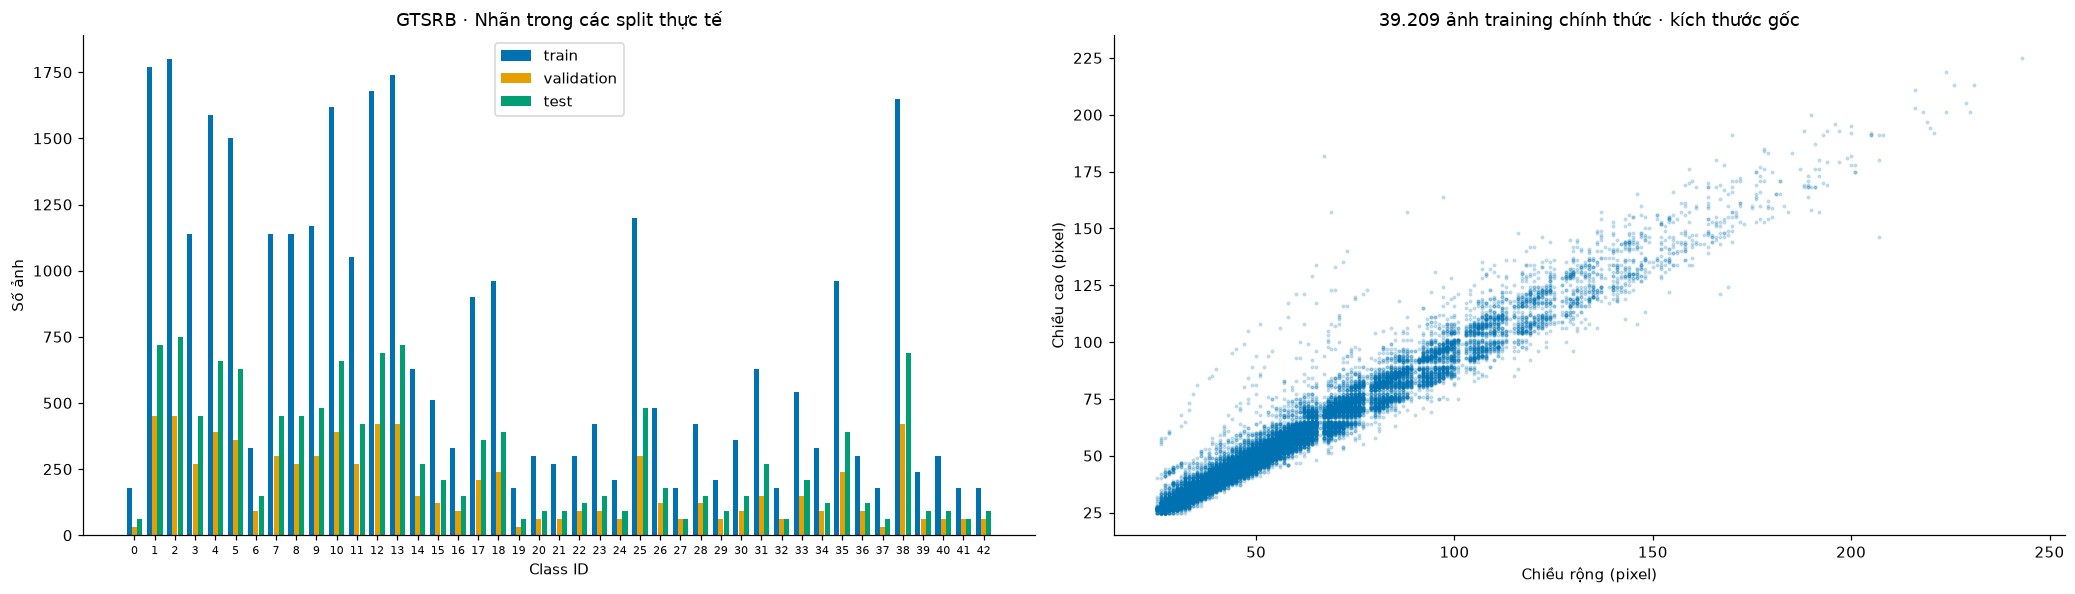

| ID | Ý nghĩa | Train | Validation | Test |
|---:|---|---:|---:|---:|
| 0 | Speed limit 20 | 180 | 30 | 60 |
| 1 | Speed limit 30 | 1,770 | 450 | 720 |
| 2 | Speed limit 50 | 1,800 | 450 | 750 |
| 3 | Speed limit 60 | 1,140 | 270 | 450 |
| 4 | Speed limit 70 | 1,590 | 390 | 660 |
| 5 | Speed limit 80 | 1,500 | 360 | 630 |
| 6 | End speed limit 80 | 330 | 90 | 150 |
| 7 | Speed limit 100 | 1,140 | 300 | 450 |
| 8 | Speed limit 120 | 1,140 | 270 | 450 |
| 9 | No passing | 1,170 | 300 | 480 |
| 10 | No passing >3.5t | 1,620 | 390 | 660 |
| 11 | Right-of-way intersection | 1,050 | 270 | 420 |
| 12 | Priority road | 1,680 | 420 | 690 |
| 13 | Yield | 1,740 | 420 | 720 |
| 14 | Stop | 630 | 150 | 270 |
| 15 | No vehicles | 510 | 120 | 210 |
| 16 | Vehicles >3.5t prohibited | 330 | 90 | 150 |
| 17 | No entry | 900 | 210 | 360 |
| 18 | General caution | 960 | 240 | 390 |
| 19 | Dangerous curve left | 180 | 30 | 60 |
| 20 | Dangerous curve right | 300 | 60 | 90 |
| 21 | Double curve | 270 | 60 | 90 |
| 22 | Bumpy road | 300 | 90 | 120 |
| 23 | Slippery road | 420 | 90 | 150 |
| 24 | Road narrows right | 210 | 60 | 90 |
| 25 | Road work | 1,200 | 300 | 480 |
| 26 | Traffic signals | 480 | 120 | 180 |
| 27 | Pedestrians | 180 | 60 | 60 |
| 28 | Children crossing | 420 | 120 | 150 |
| 29 | Bicycle crossing | 210 | 60 | 90 |
| 30 | Ice/snow caution | 360 | 90 | 150 |
| 31 | Wild animals crossing | 630 | 150 | 270 |
| 32 | End speed/passing limits | 180 | 60 | 60 |
| 33 | Turn right ahead | 540 | 149 | 210 |
| 34 | Turn left ahead | 330 | 90 | 120 |
| 35 | Ahead only | 960 | 240 | 390 |
| 36 | Straight or right | 300 | 90 | 120 |
| 37 | Straight or left | 180 | 30 | 60 |
| 38 | Keep right | 1,650 | 420 | 690 |
| 39 | Keep left | 240 | 60 | 90 |
| 40 | Roundabout mandatory | 300 | 60 | 90 |
| 41 | End no passing | 180 | 60 | 60 |
| 42 | End no passing >3.5t | 180 | 60 | 90 |

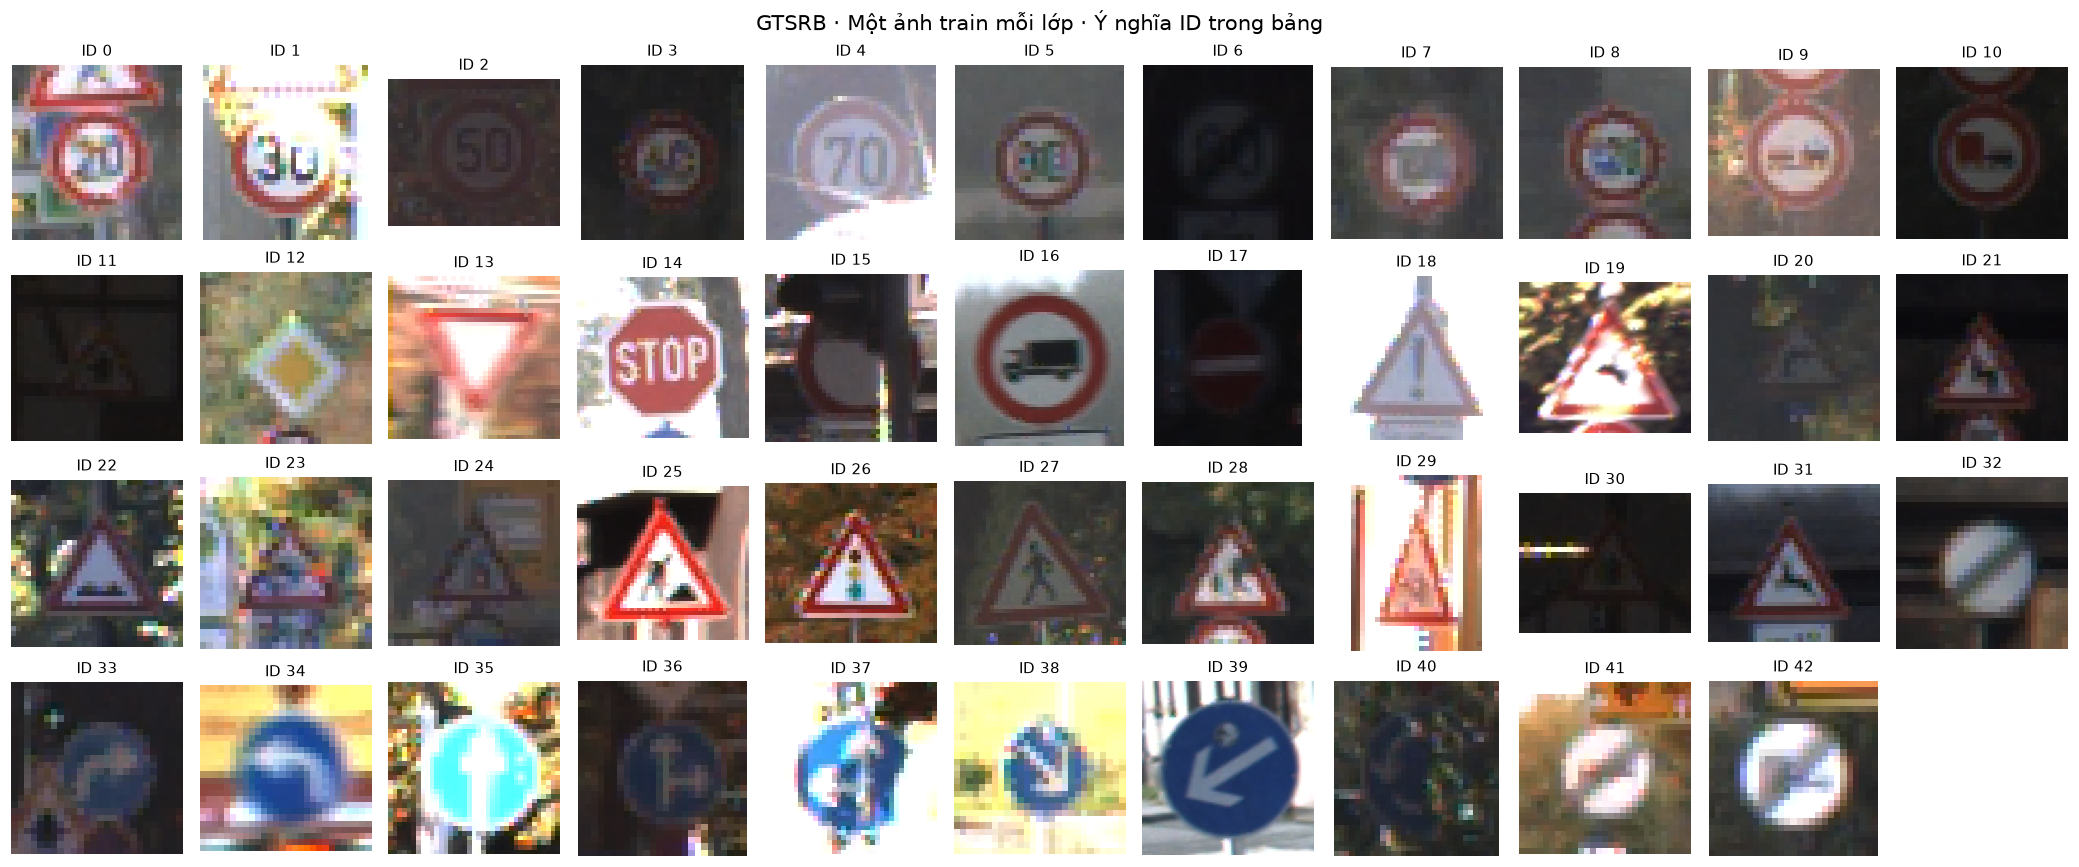

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(19, 5.5))
positions = np.arange(43)
for offset, split, color in [
    (-0.26, "train", "#0072B2"),
    (0, "validation", "#E69F00"),
    (0.26, "test", "#009E73"),
]:
    axes[0].bar(
        positions + offset, SPLIT_COUNTS[split], width=0.25, label=split, color=color
    )
axes[0].set(
    xlabel="Class ID", ylabel="Số ảnh", title="GTSRB · Nhãn trong các split thực tế"
)
axes[0].set_xticks(positions)
axes[0].tick_params(axis="x", labelsize=7)
axes[0].legend()
rows_for_size = prepared_train + prepared_val
axes[1].scatter(
    [r["width"] for r in rows_for_size],
    [r["height"] for r in rows_for_size],
    s=3,
    alpha=0.18,
    color="#0072B2",
)
axes[1].set(
    xlabel="Chiều rộng (pixel)",
    ylabel="Chiều cao (pixel)",
    title="39.209 ảnh training chính thức · kích thước gốc",
)
show_figure(fig, "eda_distribution_resolution")
lines = ["| ID | Ý nghĩa | Train | Validation | Test |", "|---:|---|---:|---:|---:|"]
for label, name in enumerate(CLASS_NAMES):
    lines.append(
        f"| {label} | {name} | {SPLIT_COUNTS['train'][label]:,} | "
        f"{SPLIT_COUNTS['validation'][label]:,} | {SPLIT_COUNTS['test'][label]:,} |"
    )
display(Markdown("\n".join(lines)))
fig, axes = plt.subplots(4, 11, figsize=(19, 8))
for ax in axes.flat:
    ax.axis("off")
for label, ax in enumerate(list(axes.flat)[:43]):
    row = next(r for r in prepared_train if r["label"] == label)
    with Image.open(row["path"]) as image:
        ax.imshow(image)
    ax.set_title(f"ID {label}", fontsize=10)
fig.suptitle("GTSRB · Một ảnh train mỗi lớp · Ý nghĩa ID trong bảng", fontsize=14)
show_figure(fig, "class_examples")

## 4. Kiến trúc CNN và Transformer
ResNet-50: bottleneck block 3/4/6/3, expansion4 và ResNet V1.5 stride ở Conv3×3, global average pooling, head 43 lớp.
DeiT-Small/16: patch16 tại 224×224 → 196 patch + CLS, D=384, 12 block, 6 head,
FFN ratio4, LayerNorm eps=10⁻⁶ và head 43 lớp. Attention được viết bằng Linear/matmul/
softmax; không dùng trainer cấp cao. Model trả logits cho cross-entropy;
softmax(logits) là xác suất, argmax cho nhãn.

Nguồn kiến trúc/pretrained: [Torchvision ResNet-50](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet50.html),
[DeiT chính thức](https://github.com/facebookresearch/deit/blob/main/README_deit.md).
DeiT dùng checkpoint **non-distilled**, ImageNet-1K; không có teacher/distillation head.
Đây là protocol fine-tune GTSRB chung, không phải tái hiện toàn bộ recipe pretraining DeiT.

In [6]:
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, incoming, channels, stride=1):
        super().__init__()
        outgoing = channels * self.expansion
        self.conv1 = nn.Conv2d(incoming, channels, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        # ResNet V1.5: spatial stride is on the 3x3 convolution, matching torchvision.
        self.conv2 = nn.Conv2d(channels, channels, 3, stride, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.conv3 = nn.Conv2d(channels, outgoing, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(outgoing)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = (
            nn.Sequential(
                nn.Conv2d(incoming, outgoing, 1, stride, bias=False),
                nn.BatchNorm2d(outgoing),
            )
            if stride != 1 or incoming != outgoing
            else None
        )

    def forward(self, x):
        identity = x if self.downsample is None else self.downsample(x)
        y = self.relu(self.bn1(self.conv1(x)))
        y = self.relu(self.bn2(self.conv2(y)))
        y = self.bn3(self.conv3(y))
        return self.relu(y + identity)


class ResNet50(nn.Module):
    def __init__(self, classes=43):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 7, 2, 3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, 2, 1)
        self.layer1 = self.make_layer(64, 64, 3)
        self.layer2 = self.make_layer(256, 128, 4, 2)
        self.layer3 = self.make_layer(512, 256, 6, 2)
        self.layer4 = self.make_layer(1024, 512, 3, 2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(2048, classes)
        self.frozen_modules = []
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(
                    module.weight, mode="fan_out", nonlinearity="relu"
                )

    @staticmethod
    def make_layer(incoming, channels, count, stride=1):
        return nn.Sequential(
            Bottleneck(incoming, channels, stride),
            *[Bottleneck(channels * 4, channels) for _ in range(count - 1)],
        )

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer4(self.layer3(self.layer2(self.layer1(x))))
        return self.fc(self.avgpool(x).flatten(1))

    def enforce_freeze(self):
        for module in self.frozen_modules:
            module.eval()


class PatchEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(3, 384, 16, 16)

    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)


class Attention(nn.Module):
    def __init__(self):
        super().__init__()
        self.qkv = nn.Linear(384, 384 * 3)
        self.proj = nn.Linear(384, 384)

    def forward(self, x):
        batch, tokens, dim = x.shape
        q, k, v = (
            self.qkv(x)
            .reshape(batch, tokens, 3, 6, 64)
            .permute(2, 0, 3, 1, 4)
            .unbind(0)
        )
        weights = (q @ k.transpose(-2, -1) / 8).softmax(-1)
        return self.proj((weights @ v).transpose(1, 2).reshape(batch, tokens, dim))


class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(384, 1536)
        self.fc2 = nn.Linear(1536, 384)

    def forward(self, x):
        return self.fc2(F.gelu(self.fc1(x)))


class DeiTBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.norm1 = nn.LayerNorm(384, eps=1e-6)
        self.attn = Attention()
        self.norm2 = nn.LayerNorm(384, eps=1e-6)
        self.mlp = FeedForward()

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        return x + self.mlp(self.norm2(x))


class DeiTSmall(nn.Module):
    def __init__(self, classes=43):
        super().__init__()
        self.patch_embed = PatchEmbedding()
        self.cls_token = nn.Parameter(torch.zeros(1, 1, 384))
        self.pos_embed = nn.Parameter(torch.zeros(1, 197, 384))
        self.blocks = nn.Sequential(*[DeiTBlock() for _ in range(12)])
        self.norm = nn.LayerNorm(384, eps=1e-6)
        self.head = nn.Linear(384, classes)
        self.frozen_modules = []
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.patch_embed(x)
        x = (
            torch.cat([self.cls_token.expand(x.shape[0], -1, -1), x], 1)
            + self.pos_embed
        )
        return self.head(self.norm(self.blocks(x))[:, 0])

    def enforce_freeze(self):
        for module in self.frozen_modules:
            module.eval()


log("KIẾN TRÚC", "Đã định nghĩa ResNet-50 và DeiT-Small/16; head GTSRB 43 lớp.")

[10:44:52] [KIẾN TRÚC] Đã định nghĩa ResNet-50 và DeiT-Small/16; head GTSRB 43 lớp.


## 5. Pretrained, freeze và optimizer
| Chế độ | Backbone khởi tạo | ResNet-50 được train | DeiT-Small được train | Max epoch |
|---|---|---|---|---:|
| Scratch | Random | Tất cả | Tất cả | 40 |
| Head-only | ImageNet-1K | fc | head | 25 |
| Partial | ImageNet-1K | layer4 + fc | block10–11 + final norm + head | 25 |
| Full | ImageNet-1K | Tất cả | Tất cả | 25 |

Backbone frozen có `requires_grad=False`. BatchNorm frozen luôn ở eval mode để
running mean/variance không đổi khi gọi model.train(). Pretrained backbone được nạp
đủ key/tensor/shape, chỉ bỏ head ImageNet và khởi tạo head 43 lớp.
Cache pretrained nằm trong `datasets/pretrained`, không phải kết quả training.

AdamW wd0,01. Scratch LR3×10⁻⁴; pretrained head LR10⁻³, phần backbone trainable
LR10⁻⁴. Warmup3 epoch rồi cosine theo ngân sách epoch mỗi chế độ.
Tất cả dùng cùng split, input, augmentation, effective batch128; batch cố định128 và accumulation1 cho mọi chế độ.

ResNet-50 dùng torchvision ImageNet-1K V1; DeiT-Small dùng checkpoint chính thức
non-distilled ImageNet-1K. Preprocessing GTSRB chung resize224/mean/std, không
phải tái hiện recipe/crop đánh giá ImageNet riêng của từng nguồn pretrained.

In [7]:
WEIGHTS = ROOT / "datasets" / "pretrained"
torch.hub.set_dir(str(WEIGHTS))


def load_pretrained(model, family):
    if family == "resnet50":
        weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V1.get_state_dict(
            progress=False, check_hash=True
        )
        head_prefix = "fc."
    else:
        weights = torch.hub.load_state_dict_from_url(
            "https://dl.fbaipublicfiles.com/deit/deit_small_patch16_224-cd65a155.pth",
            map_location="cpu",
            check_hash=True,
            progress=False,
            weights_only=True,
        )["model"]
        head_prefix = "head."
    backbone = {k: v for k, v in weights.items() if not k.startswith(head_prefix)}
    # The original ImageNet ResNet checkpoint predates num_batches_tracked buffers.
    for k, v in model.state_dict().items():
        if k.endswith("num_batches_tracked") and k not in backbone:
            backbone[k] = torch.zeros_like(v)
    expected = {k for k in model.state_dict() if not k.startswith(head_prefix)}
    assert set(backbone) == expected, (
        set(backbone) - expected,
        expected - set(backbone),
    )
    missing, unexpected = model.load_state_dict(backbone, strict=False)
    assert (
        set(missing) == {head_prefix + "weight", head_prefix + "bias"}
        and not unexpected
    )
    log(
        "PRETRAINED",
        f"{FAMILY_LABELS[family]}: đã nạp đủ {len(backbone)} tensor backbone; bỏ head ImageNet.",
        console=False,
    )


def configure_freeze(model, family, regime):
    for p in model.parameters():
        p.requires_grad_(regime in ["scratch", "full"])
    head = model.fc if family == "resnet50" else model.head
    for p in head.parameters():
        p.requires_grad_(True)
    if regime == "partial":
        modules = (
            [model.layer4] if family == "resnet50" else [model.blocks[-2:], model.norm]
        )
        for module in modules:
            for p in module.parameters():
                p.requires_grad_(True)
    model.frozen_modules = [
        module
        for module in model.modules()
        if isinstance(module, nn.BatchNorm2d)
        and not any(p.requires_grad for p in module.parameters())
    ]
    model.enforce_freeze()
    head_ids = {id(p) for p in head.parameters()}

    if regime == "scratch":
        groups = [
            {"params": [p for p in model.parameters() if p.requires_grad], "lr": 3e-4}
        ]
    else:
        backbone = [
            p for p in model.parameters() if p.requires_grad and id(p) not in head_ids
        ]
        groups = ([{"params": backbone, "lr": 1e-4}] if backbone else []) + [
            {"params": list(head.parameters()), "lr": 1e-3}
        ]
    trainable_ids = {id(p) for p in model.parameters() if p.requires_grad}
    optimizer_ids = [id(p) for group in groups for p in group["params"]]
    assert (
        len(optimizer_ids) == len(set(optimizer_ids))
        and set(optimizer_ids) == trainable_ids
    )
    return groups


def make_model(family, regime, *, pretrained=True):
    if family not in FAMILY_LABELS or regime not in REGIME_LABELS:
        raise ValueError((family, regime))
    model = ResNet50() if family == "resnet50" else DeiTSmall()
    if pretrained and regime != "scratch":
        load_pretrained(model, family)
    groups = configure_freeze(model, family, regime)
    return model, groups


def make_spec(family, regime, seed=42, augment=True, kind="main"):
    run = f"{family}_{regime}_seed{seed}" + ("_noaug" if not augment else "")
    label = f"{FAMILY_LABELS[family]} · {REGIME_LABELS[regime]}"
    label += f" · seed{seed}" + (" · no augmentation" if not augment else "")
    MODEL_LABELS[run] = label
    MODEL_TICKS[run] = (
        FAMILY_LABELS[family]
        + "\n"
        + REGIME_LABELS[regime].replace("Pretrained · ", "")
    )
    MODEL_COLORS[run] = REGIME_COLORS[regime]
    return {
        "run": run,
        "model": label,
        "family": family,
        "regime": regime,
        "seed": seed,
        "augment": augment,
        "kind": kind,
        "max_epochs": SCRATCH_EPOCHS if regime == "scratch" else PRETRAINED_EPOCHS,
    }


MAIN_SPECS = [
    make_spec(family, regime) for family in FAMILY_LABELS for regime in REGIME_ORDER
]

## 6. Kiểm chứng trên GPU trước thí nghiệm
ResNet đối chiếu forward với torchvision khi cùng state. Attention DeiT đối chiếu
forward/backward với nn.MultiheadAttention khi cùng projections. Với từng họ và
mức freeze: chạy optimizer step, xác nhận head thay đổi, mọi weights/buffer frozen
giữ nguyên; kiểm tra head43, gradient CUDA và tỷ lệ trainable. Kiểm chứng không
được dùng làm số liệu accuracy cuối.

In [8]:
def verify_architectures_and_freeze():
    log(
        "KIỂM CHỨNG",
        "ResNet reference, attention reference và optimizer step cho freeze modes trên CUDA.",
    )
    seed_all(SEED)
    mine = ResNet50(classes=1000).to(DEVICE).eval()
    reference = torchvision.models.resnet50(weights=None).to(DEVICE).eval()
    reference.load_state_dict(mine.state_dict(), strict=True)
    sample = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
    with torch.no_grad():
        torch.testing.assert_close(
            mine(sample), reference(sample), atol=1e-5, rtol=1e-5
        )
    log("RESNET", "Forward khớp torchvision khi dùng cùng weights.")
    del mine, reference
    manual = Attention().to(device=DEVICE, dtype=torch.float64)
    reference = nn.MultiheadAttention(384, 6, batch_first=True, dropout=0).to(
        device=DEVICE, dtype=torch.float64
    )
    with torch.no_grad():
        reference.in_proj_weight.copy_(manual.qkv.weight)
        reference.in_proj_bias.copy_(manual.qkv.bias)
        reference.out_proj.weight.copy_(manual.proj.weight)
        reference.out_proj.bias.copy_(manual.proj.bias)
    x = torch.randn(2, 17, 384, device=DEVICE, dtype=torch.float64, requires_grad=True)
    y = x.detach().clone().requires_grad_(True)
    actual = manual(x)
    expected = reference(y, y, y, need_weights=False)[0]
    torch.testing.assert_close(actual, expected, atol=1e-9, rtol=1e-9)
    actual.square().mean().backward()
    expected.square().mean().backward()
    torch.testing.assert_close(x.grad, y.grad, atol=1e-9, rtol=1e-9)
    for a, b in [
        (manual.qkv.weight, reference.in_proj_weight),
        (manual.qkv.bias, reference.in_proj_bias),
        (manual.proj.weight, reference.out_proj.weight),
        (manual.proj.bias, reference.out_proj.bias),
    ]:
        torch.testing.assert_close(a.grad, b.grad, atol=1e-9, rtol=1e-9)
    log(
        "DEIT ATTENTION",
        "Forward, input gradient và QKV/output gradients khớp PyTorch float64.",
    )
    del manual, reference, x, y, actual, expected
    reports = []
    for family in FAMILY_LABELS:
        for regime in REGIME_ORDER:
            seed_all(SEED)
            model, groups = make_model(family, regime)
            model.to(DEVICE)
            frozen = {
                k: p.detach().clone()
                for k, p in model.named_parameters()
                if not p.requires_grad
            }
            buffers = {
                k: b.detach().clone()
                for k, b in model.named_buffers()
                if k.rsplit(".", 1)[0]
                in {
                    name
                    for name, m in model.named_modules()
                    if isinstance(m, nn.BatchNorm2d)
                    and not any(p.requires_grad for p in m.parameters())
                }
            }
            head = model.fc if family == "resnet50" else model.head
            old_head = head.weight.detach().clone()
            optimizer = torch.optim.SGD(
                [p for p in model.parameters() if p.requires_grad], lr=1e-3
            )
            model.train()
            model.enforce_freeze()
            logits = model(sample)
            assert logits.shape == (2, 43) and logits.is_cuda
            loss = F.cross_entropy(logits, torch.tensor([0, 1], device=DEVICE))
            loss.backward()
            assert all(
                p.grad is None for p in model.parameters() if not p.requires_grad
            )
            assert all(
                p.grad is not None and p.grad.is_cuda and torch.isfinite(p.grad).all()
                for p in model.parameters()
                if p.requires_grad
            )
            optimizer.step()
            assert not torch.equal(old_head, head.weight)
            current = model.state_dict()
            assert all(
                torch.equal(value, current[key]) for key, value in frozen.items()
            )
            assert all(
                torch.equal(value, current[key]) for key, value in buffers.items()
            )
            count = sum(p.numel() for p in model.parameters())
            active = sum(p.numel() for p in model.parameters() if p.requires_grad)
            reports.append((family, regime, count, active))
            del (
                model,
                groups,
                optimizer,
                frozen,
                buffers,
                head,
                old_head,
                current,
                logits,
                loss,
            )
            torch.cuda.empty_cache()
    del sample
    lines = [
        "| Họ | Chế độ | Tổng tham số | Trainable | Trainable (%) |",
        "|---|---|---:|---:|---:|",
    ]
    for family, regime, count, active in reports:
        lines.append(
            f"| {FAMILY_LABELS[family]} | {REGIME_LABELS[regime]} | {count:,} | {active:,} | {100 * active / count:.2f} |"
        )
    display(Markdown("\n".join(lines)))
    return reports


CAPACITY_CHECKS = verify_architectures_and_freeze()

[10:44:52] [KIỂM CHỨNG] ResNet reference, attention reference và optimizer step cho freeze modes trên CUDA.
[10:44:52] [RESNET] Forward khớp torchvision khi dùng cùng weights.
[10:44:52] [DEIT ATTENTION] Forward, input gradient và QKV/output gradients khớp PyTorch float64.


| Họ | Chế độ | Tổng tham số | Trainable | Trainable (%) |
|---|---|---:|---:|---:|
| ResNet-50 | Scratch | 23,596,139 | 23,596,139 | 100.00 |
| ResNet-50 | Pretrained · head-only | 23,596,139 | 88,107 | 0.37 |
| ResNet-50 | Pretrained · partial | 23,596,139 | 15,052,843 | 63.79 |
| ResNet-50 | Pretrained · full | 23,596,139 | 23,596,139 | 100.00 |
| DeiT-Small/16 | Scratch | 21,682,219 | 21,682,219 | 100.00 |
| DeiT-Small/16 | Pretrained · head-only | 21,682,219 | 16,555 | 0.08 |
| DeiT-Small/16 | Pretrained · partial | 21,682,219 | 3,566,251 | 16.45 |
| DeiT-Small/16 | Pretrained · full | 21,682,219 | 21,682,219 | 100.00 |

## 7. Training loop, accumulation và early stopping
Forward → cross-entropy tổng theo ảnh → AMP backward → chia gradient cho **số ảnh
thực trong accumulation window** → clip norm1 → AdamW.step. Window cuối không bị
bỏ dù batch cuối nhỏ. Frozen BatchNorm giữ eval; chỉ trainable params vào optimizer.

Checkpoint theo minimum validation loss tuyệt đối. Patience4 reset khi cải thiện
**hơn min_delta=0,0001** so với mốc dừng; cải thiện nhỏ hơn vẫn có thể giữ weights tốt hơn.
Validation/test: eval + no_grad, FP32, không augmentation. Dừng sớm độc lập từng model.
Log kiểm tra CUDA ở batch/update đầu và ghi đầy đủ metric mỗi epoch trong RAM.


### Batch cố định và tài nguyên
Train, validation và test dùng **batch128**, accumulation1 cho cả hai họ và mọi
freeze mode. Effective batch128; batch cuối nhỏ hơn vẫn được giữ và chuẩn hóa
gradient theo số ảnh thực tế. Cấu hình là hằng số trong cell cấu hình.

Inference benchmark dùng batch32 chung để so sánh tốc độ.



In [9]:
def class_metrics(cm):
    true_positive = np.diag(cm).astype(np.float64)
    predicted = cm.sum(axis=0)
    support = cm.sum(axis=1)
    precision = np.divide(
        true_positive, predicted, out=np.zeros_like(true_positive), where=predicted > 0
    )
    recall = np.divide(
        true_positive, support, out=np.zeros_like(true_positive), where=support > 0
    )
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(true_positive),
        where=(precision + recall) > 0,
    )
    return precision, recall, f1


@torch.no_grad()
def evaluate(model, loader, *, run, split, progress=None):
    model.eval()
    started = time.perf_counter()
    count, loss_sum = 0, 0.0
    cm = torch.zeros(43, 43, dtype=torch.int64, device=DEVICE)
    mistakes = {}
    unique_cm = torch.zeros_like(cm) if split == "test" else None
    if progress:
        progress.start_phase(
            split,
            len(loader),
            len(loader.dataset),
            status=f"Đánh giá {split} · FP32/eval/no_grad.",
        )
    for step, (images, labels) in enumerate(loader, 1):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        logits = model(images)
        assert logits.device == DEVICE and labels.device == DEVICE
        loss = F.cross_entropy(logits, labels, reduction="sum")
        if not torch.isfinite(loss):
            raise FloatingPointError(f"Non-finite {split} loss: {run}")
        prediction = logits.argmax(dim=1)
        cm += torch.bincount(labels * 43 + prediction, minlength=43 * 43).reshape(
            43, 43
        )
        if unique_cm is not None:
            # Test loader is sequential; row offsets identify overlap independently of predictions.
            batch_rows = loader.dataset.rows[count : count + len(labels)]
            keep = torch.tensor(
                [r["sha256"] not in TEST_OVERLAP_HASHES for r in batch_rows],
                device=DEVICE,
                dtype=torch.bool,
            )
            unique_cm += torch.bincount(
                labels[keep] * 43 + prediction[keep], minlength=43 * 43
            ).reshape(43, 43)
        loss_sum += float(loss)
        count += len(labels)
        if split == "test" or split == "validation best checkpoint":
            labels_cpu = labels.cpu().tolist()
            predictions_cpu = prediction.cpu().tolist()
            for j, (truth, predicted) in enumerate(zip(labels_cpu, predictions_cpu)):
                if truth != predicted and truth not in mistakes:
                    mistakes[truth] = (
                        images[j].detach().cpu().clone(),
                        truth,
                        predicted,
                    )
        if step == 1 and progress:
            progress.update(force=True, eval_verified=True)
            log(
                "GPU EVAL",
                f"images={images.device}, labels={labels.device}, logits={logits.device}; eval/no_grad.",
                MODEL_LABELS[run],
                console=False,
            )
        if progress:
            progress.update(
                step=step,
                samples=count,
                loss=loss_sum / count,
                accuracy=float(cm.diag().sum()) / count,
                vram=torch.cuda.memory_allocated(DEVICE) / 2**20,
            )
    assert count == len(loader.dataset) and int(cm.sum()) == count
    matrix = cm.cpu().numpy()
    _precision, _recall, f1 = class_metrics(matrix)
    metrics = {
        "loss": loss_sum / count,
        "accuracy": float(np.trace(matrix) / count),
        "macro_f1": float(f1.mean()),
        "cm": matrix,
        "mistakes": mistakes,
        "samples": count,
        "seconds": time.perf_counter() - started,
    }
    if unique_cm is not None:
        unique_matrix = unique_cm.cpu().numpy()
        unique_samples = int(unique_matrix.sum())
        assert unique_samples > 0
        metrics["unique_test"] = {
            "samples": unique_samples,
            "cm": unique_matrix,
            "accuracy": float(np.trace(unique_matrix) / unique_samples),
            "macro_f1": float(class_metrics(unique_matrix)[2].mean()),
        }
    if progress:
        progress.update(
            force=True,
            step=len(loader),
            samples=count,
            loss=metrics["loss"],
            accuracy=metrics["accuracy"],
            status=f"Đã đánh giá {count:,} ảnh {split}.",
        )
        field = "test" if split == "test" else "validation"
        progress.update(
            force=True,
            **{
                field: f"{split}: loss={metrics['loss']:.4f}, "
                f"acc={100 * metrics['accuracy']:.2f}%",
                f"{field}_macro_f1": metrics["macro_f1"],
            },
        )
    log(
        "ĐÁNH GIÁ",
        f"{split}: {count:,} ảnh | accuracy={100 * metrics['accuracy']:.2f}% | "
        f"F1={metrics['macro_f1']:.4f}.",
        MODEL_LABELS[run],
        console=False,
    )
    return metrics


def make_loader(dataset, *, batch_size, shuffle=False, seed=42):
    options = {
        "num_workers": NUM_WORKERS,
        "pin_memory": True,
        "generator": torch.Generator().manual_seed(seed),
    }
    return DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=False, **options
    )


def train_one(spec, *, train_data=None, validation_data=None):
    run = spec["run"]
    seed_all(spec["seed"])
    train_data = training_dataset(spec["augment"]) if train_data is None else train_data
    validation_data = val_set if validation_data is None else validation_data
    micro_batch = BATCH_SIZE
    accumulation = ACCUMULATION_STEPS
    evaluation_batch = BATCH_SIZE
    train_loader = make_loader(
        train_data, batch_size=micro_batch, shuffle=True, seed=spec["seed"]
    )
    validation_loader = make_loader(validation_data, batch_size=evaluation_batch)
    model, groups = make_model(spec["family"], spec["regime"])
    model.to(DEVICE)
    parameters = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    protocol = {
        **spec,
        "run_id": RUN_ID,
        "split_hash": SPLIT_HASH,
        "versions": VERSIONS,
        "image_size": IMAGE_SIZE,
        "micro_batch": micro_batch,
        "accumulation": accumulation,
        "effective_batch": EFFECTIVE_BATCH,
        "cpu_threads": CPU_THREADS,
        "batch_policy": "fixed / keep final batch",
        "evaluation_batch": evaluation_batch,
        "train_images": len(train_data),
        "validation_images": len(validation_data),
        "optimizer": "AdamW",
        "weight_decay": WEIGHT_DECAY,
        "gradient_clip": GRAD_CLIP,
        "warmup_epochs": min(WARMUP_EPOCHS, spec["max_epochs"]),
        "schedule": "cosine",
        "group_lrs": [g["lr"] for g in groups],
        "patience": EARLY_STOP_PATIENCE,
        "min_delta": EARLY_STOP_MIN_DELTA,
        "checkpoint_metric": "validation loss",
        "selection_metric": "validation accuracy / macro-F1 / -loss",
        "normalization": "ImageNet mean/std",
        "architecture": str(model),
    }
    RUN_CONFIGS[run] = protocol
    optimizer = torch.optim.AdamW(groups, weight_decay=WEIGHT_DECAY)
    warmup = min(WARMUP_EPOCHS, spec["max_epochs"])

    def lr_factor(epoch):
        if epoch < warmup:
            return (epoch + 1) / warmup
        fraction = (epoch - warmup) / max(1, spec["max_epochs"] - warmup)
        return 0.5 * (1 + math.cos(math.pi * min(1, fraction)))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_factor)
    scaler = torch.amp.GradScaler("cuda", init_scale=1024)
    progress = TextProgress(spec["model"])
    progress.update(
        force=True,
        max_epochs=spec["max_epochs"],
        batch_config=f"batch={micro_batch}; accumulation={accumulation}; "
        f"effective={EFFECTIVE_BATCH}; eval FP32={evaluation_batch}",
    )
    history = []
    best_loss = math.inf
    monitor_loss = math.inf
    bad = 0
    total_updates = 0
    total_skips = 0
    stopping_reason = "max_epochs"
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats(DEVICE)
    log(
        "TRAIN",
        f"{spec['model']} | {len(train_data):,} ảnh | {parameters:,} params / "
        f"{trainable:,} trainable | augmentation={spec['augment']} | {len(train_loader):,} batch/epoch.",
    )
    for epoch in range(1, spec["max_epochs"] + 1):
        torch.cuda.synchronize()
        started = time.perf_counter()
        model.train()
        model.enforce_freeze()
        optimizer.zero_grad(set_to_none=True)
        loss_sum = 0.0
        count = 0
        correct = 0
        window_images = 0
        updates = 0
        skips = 0
        lrs = [group["lr"] for group in optimizer.param_groups]
        progress.start_phase(
            "TRAIN",
            len(train_loader),
            len(train_data),
            epoch=epoch,
            updates=0,
            skips=0,
            status="Forward → backward → AdamW trên CUDA · accumulation đúng số ảnh.",
        )
        for step, (images, labels) in enumerate(train_loader, 1):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            with torch.autocast("cuda"):
                logits = model(images)
                loss = F.cross_entropy(logits, labels, reduction="sum")
            if not torch.isfinite(loss):
                raise FloatingPointError(f"Non-finite training loss: {run}")
            scaler.scale(loss / EFFECTIVE_BATCH).backward()
            window_images += len(labels)
            if step % accumulation == 0 or step == len(train_loader):
                scaler.unscale_(optimizer)
                gradients = [
                    p.grad
                    for p in model.parameters()
                    if p.requires_grad and p.grad is not None
                ]
                assert gradients and all(g.is_cuda for g in gradients)
                for gradient in gradients:
                    gradient.mul_(EFFECTIVE_BATCH / window_images)
                assert all(
                    p.grad is None for p in model.parameters() if not p.requires_grad
                )
                nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad], GRAD_CLIP
                )
                old_scale = scaler.get_scale()
                scaler.step(optimizer)
                scaler.update()
                did_update = scaler.get_scale() >= old_scale
                updates += int(did_update)
                skips += int(not did_update)
                if epoch == 1 and step <= accumulation:
                    assert images.is_cuda and labels.is_cuda and logits.is_cuda
                    progress.update(force=True, train_verified=True)
                    log(
                        "GPU TRAIN",
                        f"params/images/labels/logits/gradients đều CUDA; "
                        f"{trainable:,} trainable; frozen gradients=None.",
                        spec["model"],
                        console=False,
                    )
                optimizer.zero_grad(set_to_none=True)
                del gradients
                window_images = 0
            loss_sum += float(loss.detach())
            count += len(labels)
            correct += int((logits.argmax(dim=1) == labels).sum())
            progress.update(
                step=step,
                samples=count,
                loss=loss_sum / count,
                accuracy=correct / count,
                updates=updates,
                skips=skips,
                vram=torch.cuda.memory_allocated(DEVICE) / 2**20,
            )
        assert count == len(train_data)
        assert updates + skips == math.ceil(len(train_data) / EFFECTIVE_BATCH)
        validation = evaluate(
            model,
            validation_loader,
            run=run,
            split=f"validation epoch {epoch}",
            progress=progress,
        )
        current_loss = validation["loss"]
        if current_loss < best_loss:
            best_loss = current_loss
            remember_checkpoint(
                run,
                {"model": model.state_dict(), "epoch": epoch, "val_loss": best_loss},
            )
        if current_loss < monitor_loss - EARLY_STOP_MIN_DELTA:
            monitor_loss = current_loss
            bad = 0
        else:
            bad += 1
        if updates:
            scheduler.step()
        torch.cuda.synchronize()
        row = {
            "epoch": epoch,
            "train_loss": loss_sum / count,
            "train_accuracy": correct / count,
            "val_loss": current_loss,
            "val_accuracy": validation["accuracy"],
            "val_macro_f1": validation["macro_f1"],
            "seconds": time.perf_counter() - started,
            "train_samples": count,
            "train_batches": len(train_loader),
            "optimizer_updates": updates,
            "amp_skips": skips,
            "lr": lrs,
            "early_stop_counter": bad,
        }
        history.append(row)
        total_updates += updates
        total_skips += skips
        log(
            "EPOCH",
            f"{epoch}/{spec['max_epochs']} | train loss={row['train_loss']:.4f}, "
            f"acc={100 * row['train_accuracy']:.2f}% | val loss={current_loss:.4f}, "
            f"acc={100 * row['val_accuracy']:.2f}% | updates={updates}, AMP skips={skips} | LR={lrs}.",
            spec["model"],
            console=False,
        )
        progress.update(
            force=True,
            bad=bad,
            checkpoint=f"Best epoch {CHECKPOINTS[run]['epoch']} · val loss={best_loss:.5f}",
            status=f"Epoch hoàn tất · LR={', '.join(f'{lr:.2g}' for lr in lrs)} · {row['seconds']:.2f}s/epoch.",
        )
        if bad >= EARLY_STOP_PATIENCE:
            stopping_reason = "early_stopping"
            break
    state = load_checkpoint(run)
    model.load_state_dict(state["model"], strict=True)
    validation = evaluate(
        model,
        validation_loader,
        run=run,
        split="validation best checkpoint",
        progress=progress,
    )
    result = {
        **spec,
        "micro_batch": micro_batch,
        "accumulation": accumulation,
        "evaluation_batch": evaluation_batch,
        "epochs": len(history),
        "optimizer_updates": total_updates,
        "amp_skips": total_skips,
        "best_epoch": state["epoch"],
        "stopping_reason": stopping_reason,
        "val_accuracy": validation["accuracy"],
        "val_macro_f1": validation["macro_f1"],
        "val_loss": validation["loss"],
        "parameters": parameters,
        "trainable": trainable,
        "seconds": sum(row["seconds"] for row in history),
        "seconds_per_epoch": sum(row["seconds"] for row in history) / len(history),
        "peak_vram_mb": torch.cuda.max_memory_allocated(DEVICE) / 2**20,
    }
    progress.update(
        force=True,
        status=f"Train hoàn tất · {len(history)} epoch / {total_updates:,} updates · "
        f"{stopping_reason} · best epoch {state['epoch']} · chờ test sau khi chốt protocol.",
    )
    del model, optimizer, groups, scheduler, scaler
    torch.cuda.empty_cache()
    return result, history, validation, progress


@torch.no_grad()
def benchmark_inference(model, images, *, warmup=5, repeats=20):
    model.eval()
    images = images.to(DEVICE)
    for _ in range(warmup):
        model(images)
    torch.cuda.synchronize()
    start, end = (
        torch.cuda.Event(enable_timing=True),
        torch.cuda.Event(enable_timing=True),
    )
    start.record()
    for _ in range(repeats):
        model(images)
    end.record()
    torch.cuda.synchronize()
    milliseconds = start.elapsed_time(end) / repeats
    return {
        "gpu_ms_per_batch": milliseconds,
        "gpu_images_per_second": len(images) * 1000 / milliseconds,
        "inference_batch": len(images),
    }


def test_all(results, evaluations, progresses):
    log(
        "TEST",
        "Protocol đã chốt bằng validation; đánh giá toàn bộ official test cho tất cả model.",
    )
    benchmark_images = next(
        iter(make_loader(test_set, batch_size=INFERENCE_BENCHMARK_BATCH))
    )[0]
    for result in results:
        run = result["run"]
        loader = make_loader(test_set, batch_size=BATCH_SIZE)
        model, _ = make_model(result["family"], result["regime"], pretrained=False)
        model.load_state_dict(load_checkpoint(run)["model"], strict=True)
        model.to(DEVICE).eval()
        metrics = evaluate(
            model, loader, run=run, split="test", progress=progresses[run]
        )
        evaluations[run]["test"] = metrics
        result.update(
            test_accuracy=metrics["accuracy"],
            test_macro_f1=metrics["macro_f1"],
            test_loss=metrics["loss"],
            test_seconds=metrics["seconds"],
        )
        unique = metrics["unique_test"]
        result.update(
            unique_test_samples=unique["samples"],
            unique_test_accuracy=unique["accuracy"],
            unique_test_macro_f1=unique["macro_f1"],
        )
        result.update(benchmark_inference(model, benchmark_images))
        progresses[run].update(
            force=True,
            status=f"HOÀN TẤT MODEL · {result['epochs']} epoch / "
            f"{result['optimizer_updates']:,} updates · đủ {metrics['samples']:,} ảnh official test · "
            f"GPU inference={result['gpu_ms_per_batch']:.2f}ms/batch.",
        )
        log(
            "TEST HOÀN TẤT",
            f"{result['model']} | test accuracy={100 * metrics['accuracy']:.2f}% "
            f"| F1={metrics['macro_f1']:.4f}.",
            console=False,
        )
        del model
        torch.cuda.empty_cache()

## 8. Tiện ích báo cáo
Learning curves: màu theo chế độ, nét đứt train / nét liền validation; CNN và
Transformer đặt ở hai panel ngang. Bảng ghi cả tổng params, trainable, thời gian/epoch
và peak GPU allocated memory. GPU inference benchmark dùng batch cố định trên GPU,
FP32/eval/no_grad, warmup5 và đo20 lần bằng CUDA Events; không gồm đọc/resize/chuyển ảnh.
Thời gian test end to end có DataLoader được ghi riêng, không lẫn với benchmark GPU.

Ma trận43 lớp trình bày hai họ đã chọn bằng validation, đặt ngang; mỗi ô có số ảnh,
ô khác0 thêm % theo lớp thật. Bảng ID/ý nghĩa và per-class metrics giúp đọc đầy đủ.
Các cấu hình còn lại có test metrics và bảng cặp lỗi nhiều nhất.

In [10]:
def result_tables(rows, title):
    display(Markdown(f"**{title} · Huấn luyện thực tế**"))
    lines = [
        "| Model | Batch × accumulation | Eval batch | Epoch | Best epoch | Updates | AMP skips | Dừng | Peak GPU (MiB) |",
        "|---|---|---:|---:|---:|---:|---:|---|---:|",
    ]
    for r in rows:
        stop = (
            "Early stopping"
            if r["stopping_reason"] == "early_stopping"
            else "Max epoch"
        )
        lines.append(
            f"| {r['model']} | {r['micro_batch']} × {r['accumulation']} | {r['evaluation_batch']} | {r['epochs']} | {r['best_epoch']} | {r['optimizer_updates']:,} | "
            f"{r['amp_skips']} | {stop} | {r['peak_vram_mb']:.0f} |"
        )
    display(Markdown("\n".join(lines)))
    lines = [
        (
            "| Model | Train acc tại best (%) | Val acc (%) | Val F1 | Test acc (%) | Test F1 | "
            "Total params | Trainable | Trainable (%) | Train + val (s) | s/epoch |"
        ),
        "|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|",
    ]
    for r in rows:
        best = next(
            row for row in histories[r["run"]] if row["epoch"] == r["best_epoch"]
        )
        lines.append(
            f"| {r['model']} | {100 * best['train_accuracy']:.2f} | {100 * r['val_accuracy']:.2f} | "
            f"{r['val_macro_f1']:.4f} | {100 * r['test_accuracy']:.2f} | {r['test_macro_f1']:.4f} | "
            f"{r['parameters']:,} | {r['trainable']:,} | {100 * r['trainable'] / r['parameters']:.2f} | "
            f"{r['seconds']:.2f} | {r['seconds_per_epoch']:.3f} |"
        )
    display(Markdown("\n".join(lines)))


def main_comparison(rows):
    names = [MODEL_TICKS[r["run"]] for r in rows]
    colors = [MODEL_COLORS[r["run"]] for r in rows]
    positions = np.arange(len(rows))
    fig, axes = plt.subplots(1, 3, figsize=(19, 8.6), sharey=True)
    for offset, key, label, hatch in [
        (-0.18, "val_accuracy", "Validation", ""),
        (0.18, "test_accuracy", "Official test", "//"),
    ]:
        bars = axes[0].barh(
            positions + offset,
            [100 * r[key] for r in rows],
            height=0.32,
            color=colors,
            label=label,
            hatch=hatch,
        )
        axes[0].bar_label(bars, fmt="%.1f", fontsize=8, padding=3)
    axes[0].set(xlim=(0, 112), xlabel="Accuracy (%)", title="Chất lượng phân loại")
    axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=9)
    for ax, key, title, xlabel, fmt in [
        (
            axes[1],
            "trainable",
            "Capacity được tối ưu",
            "Trainable parameters",
            "{:,.0f}",
        ),
        (
            axes[2],
            "seconds_per_epoch",
            "Chi phí train + validation",
            "Giây / epoch",
            "{:.2f}",
        ),
    ]:
        values = [r[key] for r in rows]
        bars = ax.barh(positions, values, height=0.62, color=colors)
        ax.bar_label(
            bars, labels=[fmt.format(v) for v in values], padding=3, fontsize=9
        )
        ax.set(title=title, xlabel=xlabel)
        ax.margins(x=0.25)
    for ax in axes:
        ax.set_yticks(positions, names, fontsize=9)
        ax.grid(axis="x", alpha=0.15)
        ax.set_axisbelow(True)
    axes[0].invert_yaxis()
    fig.suptitle(
        "A1 · Tám cấu hình chính · Full GTSRB · Cùng split và augmentation", fontsize=14
    )
    show_figure(fig, "main_comparison")


def learning_curves(rows):
    for metric, title, ylabel in [
        ("loss", "Cross-entropy loss", "Loss"),
        ("accuracy", "Accuracy (%)", "Accuracy (%)"),
    ]:
        fig, axes = plt.subplots(1, 2, figsize=(19, 7))
        for ax, family in zip(axes, FAMILY_LABELS):
            for result in [r for r in rows if r["family"] == family]:
                history = histories[result["run"]]
                epochs = [r["epoch"] for r in history]
                color = REGIME_COLORS[result["regime"]]
                label = REGIME_LABELS[result["regime"]].replace("Pretrained · ", "")
                for phase, style in [("train", "--"), ("val", "-")]:
                    values = [
                        r[f"{phase}_{metric}"] * (100 if metric == "accuracy" else 1)
                        for r in history
                    ]
                    ax.plot(
                        epochs, values, style, color=color, label=f"{label} · {phase}"
                    )
            ax.set(title=FAMILY_LABELS[family], xlabel="Epoch", ylabel=ylabel)
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))
            if metric == "accuracy":
                ax.set_ylim(0, 101)
            ax.legend(
                ncol=2,
                fontsize=8,
                loc="upper center",
                bbox_to_anchor=(0.5, -0.14),
            )
            ax.grid(alpha=0.15)
        fig.suptitle(f"A1 · {title} · Nét đứt train / nét liền validation", fontsize=14)
        show_figure(fig, f"learning_{metric}")


def direct_comparisons(rows):
    lookup = {(r["family"], r["regime"]): r for r in rows}
    lines = [
        (
            "| Cùng chế độ | CNN val (%) | ViT val (%) | ViT − CNN (điểm %) | CNN test (%) | ViT test (%) | "
            "CNN / ViT s/epoch | CNN / ViT peak MiB |"
        ),
        "|---|---:|---:|---:|---:|---:|---|---|",
    ]
    for regime in REGIME_ORDER:
        cnn, vit = [lookup[(family, regime)] for family in FAMILY_LABELS]
        lines.append(
            f"| {REGIME_LABELS[regime]} | {100 * cnn['val_accuracy']:.2f} | {100 * vit['val_accuracy']:.2f} | "
            f"{100 * (vit['val_accuracy'] - cnn['val_accuracy']):+.2f} | {100 * cnn['test_accuracy']:.2f} | "
            f"{100 * vit['test_accuracy']:.2f} | {cnn['seconds_per_epoch']:.3f} / {vit['seconds_per_epoch']:.3f} | "
            f"{cnn['peak_vram_mb']:.0f} / {vit['peak_vram_mb']:.0f} |"
        )
    display(Markdown("**CNN vs Transformer, cùng chế độ**\n\n" + "\n".join(lines)))
    lines = [
        (
            "| Họ | Pretrained full − scratch val (điểm %) | Full − head val (điểm %) | "
            "Partial − head val (điểm %) | Head / partial / full trainable |"
        ),
        "|---|---:|---:|---:|---|",
    ]
    for family, family_label in FAMILY_LABELS.items():
        scratch, head, partial, full = [lookup[(family, r)] for r in REGIME_ORDER]
        lines.append(
            f"| {family_label} | {100 * (full['val_accuracy'] - scratch['val_accuracy']):+.2f} | "
            f"{100 * (full['val_accuracy'] - head['val_accuracy']):+.2f} | "
            f"{100 * (partial['val_accuracy'] - head['val_accuracy']):+.2f} | "
            f"{head['trainable']:,} / {partial['trainable']:,} / {full['trainable']:,} |"
        )
    display(Markdown("**Scratch/pretrained và ba mức freeze**\n\n" + "\n".join(lines)))
    lines = [
        "| Model | Batch inference | GPU ms/batch | GPU images/s | Test end to end (s) |",
        "|---|---:|---:|---:|---:|",
    ]
    for r in rows:
        lines.append(
            f"| {r['model']} | {r['inference_batch']} | {r['gpu_ms_per_batch']:.2f} | "
            f"{r['gpu_images_per_second']:.1f} | {r['test_seconds']:.2f} |"
        )
    display(
        Markdown(
            "**Inference FP32 · CUDA Events, tách khỏi DataLoader**\n\n"
            + "\n".join(lines)
        )
    )


def augmentation_and_seed_report():
    augmentation = []
    for family, base in selected.items():
        noaug = next(
            r for r in results if r["family"] == family and r["kind"] == "noaug"
        )
        augmentation.append((family, base, noaug))
    lines = [
        (
            "| Họ / cấu hình cố định | Aug val (%) | No-aug val (%) | Aug − no-aug (điểm %) | "
            "Aug / no-aug test (%) |"
        ),
        "|---|---:|---:|---:|---|",
    ]
    for family, base, noaug in augmentation:
        lines.append(
            f"| {FAMILY_LABELS[family]} / {REGIME_LABELS[base['regime']]} | "
            f"{100 * base['val_accuracy']:.2f} | {100 * noaug['val_accuracy']:.2f} | "
            f"{100 * (base['val_accuracy'] - noaug['val_accuracy']):+.2f} | "
            f"{100 * base['test_accuracy']:.2f} / {100 * noaug['test_accuracy']:.2f} |"
        )
    display(
        Markdown(
            "**Ablation augmentation · Seed42, cùng cấu hình**\n\n" + "\n".join(lines)
        )
    )
    lines = [
        (
            "| Họ / cấu hình | Seeds | Val acc mean±std (%) | Test acc mean±std (%) | "
            "Val macro-F1 mean±std | Test macro-F1 mean±std |"
        ),
        "|---|---|---|---|---|---|",
    ]
    summaries = []
    for family, base in selected.items():
        replicas = [
            r
            for r in results
            if r["family"] == family
            and r["regime"] == base["regime"]
            and r["augment"]
            and r["seed"] in (42, 43, 44)
        ]
        assert len(replicas) == 3
        stats = {
            key: (
                float(np.mean([r[key] for r in replicas])),
                float(np.std([r[key] for r in replicas], ddof=1)),
            )
            for key in [
                "val_accuracy",
                "test_accuracy",
                "val_macro_f1",
                "test_macro_f1",
            ]
        }
        summaries.append({"family": family, "regime": base["regime"], "n": 3, **stats})
        lines.append(
            f"| {FAMILY_LABELS[family]} / {REGIME_LABELS[base['regime']]} | 42/43/44 | "
            f"{100 * stats['val_accuracy'][0]:.2f}±{100 * stats['val_accuracy'][1]:.2f} | "
            f"{100 * stats['test_accuracy'][0]:.2f}±{100 * stats['test_accuracy'][1]:.2f} | "
            f"{stats['val_macro_f1'][0]:.4f}±{stats['val_macro_f1'][1]:.4f} | "
            f"{stats['test_macro_f1'][0]:.4f}±{stats['test_macro_f1'][1]:.4f} |"
        )
    display(
        Markdown(
            "**Lặp ba seed · Std mẫu (ddof=1), cùng split seed42**\n\n"
            + "\n".join(lines)
        )
    )
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    x = np.arange(2)
    for offset, condition, hatch in [(-0.18, "aug", ""), (0.18, "noaug", "//")]:
        vals = [
            100 * (base if condition == "aug" else noaug)["val_accuracy"]
            for _, base, noaug in augmentation
        ]
        bars = axes[0].bar(
            x + offset,
            vals,
            width=0.34,
            label=condition,
            hatch=hatch,
            color=["#0072B2", "#E69F00"],
        )
        axes[0].bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
    axes[0].set(title="Augmentation · validation", ylabel="Accuracy (%)", ylim=(0, 112))
    axes[0].set_xticks(x, list(FAMILY_LABELS.values()))
    axes[0].legend()
    for offset, key, label in [
        (-0.18, "val_accuracy", "Validation"),
        (0.18, "test_accuracy", "Test"),
    ]:
        means = [100 * r[key][0] for r in summaries]
        stds = [100 * r[key][1] for r in summaries]
        bars = axes[1].bar(
            x + offset,
            means,
            yerr=stds,
            capsize=5,
            width=0.34,
            label=label,
            color=["#0072B2", "#E69F00"],
            hatch="" if key == "val_accuracy" else "//",
        )
        axes[1].bar_label(
            bars,
            labels=[f"{m:.2f}±{s:.2f}" for m, s in zip(means, stds)],
            padding=7,
            fontsize=9,
        )
    axes[1].set(title="Ba seed · mean ± std", ylabel="Accuracy (%)", ylim=(0, 114))
    axes[1].set_xticks(x, list(FAMILY_LABELS.values()))
    axes[1].legend()
    show_figure(fig, "augmentation_seeds")
    return summaries


def overlap_sensitivity_report(rows):
    lines = [
        "| Model | Full test acc (%) | Không trùng acc (%) | Δkhông trùng − full (điểm %) | Full F1 | Không trùng F1 | Số ảnh không trùng |",
        "|---|---:|---:|---:|---:|---:|---:|",
    ]
    for r in rows:
        lines.append(
            f"| {r['model']} | {100 * r['test_accuracy']:.2f} | "
            f"{100 * r['unique_test_accuracy']:.2f} | "
            f"{100 * (r['unique_test_accuracy'] - r['test_accuracy']):+.3f} | "
            f"{r['test_macro_f1']:.4f} | {r['unique_test_macro_f1']:.4f} | {r['unique_test_samples']:,} |"
        )
    display(
        Markdown(
            "**Độ nhạy với ảnh trùng SHA256 · full test và test không trùng**\n\n"
            + "\n".join(lines)
        )
    )

In [11]:
def error_report(rows, champions):
    fig, axes = plt.subplots(1, 2, figsize=(25, 12))
    for ax, result in zip(axes, champions.values()):
        cm = evaluations[result["run"]]["test"]["cm"]
        support = cm.sum(axis=1)
        percent = np.divide(
            cm * 100,
            support[:, None],
            out=np.zeros_like(cm, dtype=float),
            where=support[:, None] > 0,
        )
        im = ax.imshow(percent, vmin=0, vmax=100, cmap="Blues", aspect="equal")
        for i in range(43):
            for j in range(43):
                value = cm[i, j]
                ax.text(
                    j,
                    i,
                    f"{value}\n{percent[i, j]:.0f}%" if value else "0",
                    ha="center",
                    va="center",
                    fontsize=4.6 if value else 4.3,
                    color="white"
                    if percent[i, j] > 55
                    else ("#151515" if value else "#909090"),
                )
        ax.set_xticks(np.arange(43))
        ax.set_yticks(np.arange(43))
        ax.tick_params(labelsize=7)
        ax.set(
            xlabel="Nhãn dự đoán · ID lớp",
            ylabel="Nhãn thật · ID lớp",
            title=f"{result['model']}\nOfficial test · {cm.sum():,} ảnh · acc={100 * result['test_accuracy']:.2f}%",
        )
        fig.colorbar(im, ax=ax, fraction=0.045, pad=0.025, label="% theo lớp thật")
    show_figure(fig, "test_confusion_champions")
    # A readable 10x10 excerpt complements the complete 43x43 matrices.
    fig, axes = plt.subplots(1, 2, figsize=(19, 8))
    for ax, result in zip(axes, champions.values()):
        cm = evaluations[result["run"]]["test"]["cm"]
        off_diagonal = cm.copy()
        np.fill_diagonal(off_diagonal, 0)
        burden = off_diagonal.sum(axis=1) + off_diagonal.sum(axis=0)
        ids = np.sort(np.argsort(-burden, kind="stable")[:10])
        subset = cm[np.ix_(ids, ids)]
        denominator = cm.sum(axis=1)[ids, None]
        rate = np.divide(
            subset * 100,
            denominator,
            out=np.zeros_like(subset, dtype=float),
            where=denominator > 0,
        )
        im = ax.imshow(rate, vmin=0, vmax=100, cmap="Blues")
        for i in range(10):
            for j in range(10):
                ax.text(
                    j,
                    i,
                    f"{subset[i, j]}\n{rate[i, j]:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white" if rate[i, j] > 55 else "#202020",
                )
        ax.set_xticks(np.arange(10), [str(i) for i in ids])
        ax.set_yticks(np.arange(10), [str(i) for i in ids])
        ax.set(
            xlabel="ID dự đoán",
            ylabel="ID thật",
            title=f"{result['model']}\n10 lớp liên quan nhiều ảnh sai · trích từ ma trận đủ43 lớp",
        )
        fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03, label="% toàn bộ lớp thật")
    show_figure(fig, "confusion_detail_10_classes")
    lines = [
        "| Model | Lớp thật → dự đoán nhầm nhiều nhất | Số ảnh | % lớp thật |",
        "|---|---|---:|---:|",
    ]
    for r in rows:
        cm = evaluations[r["run"]]["test"]["cm"]
        wrong = cm.copy()
        np.fill_diagonal(wrong, 0)
        truth, prediction = np.unravel_index(wrong.argmax(), wrong.shape)
        count = int(wrong[truth, prediction])
        pair = (
            f"{truth}: {CLASS_NAMES[truth]} → {prediction}: {CLASS_NAMES[prediction]}"
            if count
            else "Không có lỗi"
        )
        rate = 100 * count / max(1, int(cm[truth].sum()))
        lines.append(f"| {r['model']} | {pair} | {count} | {rate:.2f}% |")
    display(
        Markdown(
            "**Cặp nhầm lẫn nhiều nhất · 8 cấu hình chính**\n\n" + "\n".join(lines)
        )
    )
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    for axs, r in zip(axes, champions.values()):
        metric = evaluations[r["run"]]["test"]
        _, recall, _ = class_metrics(metric["cm"])
        mistakes = metric["mistakes"]
        chosen = [int(i) for i in np.argsort(recall) if int(i) in mistakes][:4]
        for ax in axs:
            ax.axis("off")
        for ax, label in zip(axs, chosen):
            image, truth, prediction = mistakes[label]
            image = (
                image * torch.tensor([0.229, 0.224, 0.225])[:, None, None]
                + torch.tensor([0.485, 0.456, 0.406])[:, None, None]
            ).clamp(0, 1)
            ax.imshow(image.permute(1, 2, 0))
            ax.set_title(
                f"{FAMILY_LABELS[r['family']]} · {REGIME_LABELS[r['regime']]}\n"
                f"Thật {truth}: {CLASS_NAMES[truth]}\n"
                f"Đoán {prediction}: {CLASS_NAMES[prediction]}",
                fontsize=9,
                wrap=True,
            )
        if not chosen:
            axs[0].text(0.5, 0.5, "Không có ảnh dự đoán sai", ha="center")
    show_figure(fig, "test_error_gallery")
    families = list(champions)
    lines = [
        "| ID / ý nghĩa | Test support | CNN Precision / Recall / F1 | Transformer Precision / Recall / F1 |",
        "|---|---:|---|---|",
    ]
    matrices = [evaluations[champions[f]["run"]]["test"]["cm"] for f in families]
    metrics = [class_metrics(cm) for cm in matrices]
    for i, name in enumerate(CLASS_NAMES):
        values = [
            " / ".join(f"{metric[i]:.3f}" for metric in triple) for triple in metrics
        ]
        lines.append(
            f"| {i}: {name} | {int(matrices[0][i].sum())} | {values[0]} | {values[1]} |"
        )
    display(
        Markdown(
            "**Per-class metrics · hai cấu hình chọn bằng validation**\n\n"
            + "\n".join(lines)
        )
    )

## 9. Huấn luyện và chốt protocol bằng validation
Chạy tám cấu hình chính. Trong từng họ, chọn cấu hình bằng validation accuracy,
sau đó macro-F1, rồi loss thấp hơn nếu hòa. Lựa chọn này khóa trước khi test.
Hai cấu hình no-augmentation giữ nguyên seed42 và chế độ đã chọn; bốn lần lặp
seed43/44 giữ cùng split, augmentation và hyperparameters. Seed mới thay khởi tạo,
shuffle và augmentation, không chia lại dữ liệu.

Cả 14 run hoàn thành train/validation mới đánh giá official test. Không chọn lại
kiến trúc, chế độ, seed hoặc checkpoint từ test. Thời gian trên progress tính từ
lúc tạo run, gồm chờ các run khác; thời gian bảng chỉ cộng các epoch train/validation.

In [12]:
results, histories, evaluations, progresses = [], {}, {}, {}


def run_training(spec):
    result, history, validation, progress = train_one(spec)
    results.append(result)
    histories[spec["run"]] = history
    evaluations[spec["run"]] = {"validation": validation}
    progresses[spec["run"]] = progress


for spec in MAIN_SPECS:
    run_training(spec)
main_results = results.copy()


def validation_key(result):
    return result["val_accuracy"], result["val_macro_f1"], -result["val_loss"]


selected = {
    family: max([r for r in main_results if r["family"] == family], key=validation_key)
    for family in FAMILY_LABELS
}
extension_specs = []
for family, result in selected.items():
    extension_specs.append(
        make_spec(family, result["regime"], seed=42, augment=False, kind="noaug")
    )
    for seed in (43, 44):
        extension_specs.append(
            make_spec(family, result["regime"], seed=seed, augment=True, kind="repeat")
        )
for spec in extension_specs:
    run_training(spec)
assert len(results) == 14 and len({r["run"] for r in results}) == 14
assert all(
    config["train_images"] == 31_380
    and config["validation_images"] == 7_829
    and config["split_hash"] == SPLIT_HASH
    for config in RUN_CONFIGS.values()
)
test_all(results, evaluations, progresses)
assert all(evaluations[r["run"]]["test"]["samples"] == 12_630 for r in results)

ResNet-50 · Scratch · seed42 | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Batch: batch=128; accumulation=1; effective=128; eval FP32=128
Epoch 9/40 (giới hạn; có early stopping)
test [########################] 100.0% | batch 99/99 | ảnh 12,630/12,630
Loss=0.1489 | Accuracy=96.33% | Updates train/epoch=246 | AMP skips train/epoch=0 | VRAM=158 MiB
Validation: validation best checkpoint: loss=0.0590, acc=98.26% | Macro-F1=0.9688
Test: test: loss=0.1489, acc=96.33% | Macro-F1=0.9447
Checkpoint: Best epoch 5 · val loss=0.05899 | Early stop=4/4 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=13:41:23 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 9 epoch / 2,214 updates · đủ 12,630 ảnh official test · GPU inference=77.06ms/batch.

[10:44:55] [TRAIN] ResNet-50 · Scratch · seed42 | 31,380 ảnh | 23,596,139 params / 23,596,139 trainable | augmentation=True | 246 batch/epoch.


ResNet-50 · Pretrained · head-only · seed42 | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Batch: batch=128; accumulation=1; effective=128; eval FP32=128
Epoch 24/25 (giới hạn; có early stopping)
test [########################] 100.0% | batch 99/99 | ảnh 12,630/12,630
Loss=0.9819 | Accuracy=70.35% | Updates train/epoch=246 | AMP skips train/epoch=0 | VRAM=158 MiB
Validation: validation best checkpoint: loss=0.9831, acc=69.22% | Macro-F1=0.5952
Test: test: loss=0.9819, acc=70.35% | Macro-F1=0.6143
Checkpoint: Best epoch 20 · val loss=0.98310 | Early stop=4/4 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=13:02:45 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 24 epoch / 5,904 updates · đủ 12,630 ảnh official test · GPU inference=77.54ms/batch.

[11:24:21] [TRAIN] ResNet-50 · Pretrained · head-only · seed42 | 31,380 ảnh | 23,596,139 params / 88,107 trainable | augmentation=True | 246 batch/epoch.


ResNet-50 · Pretrained · partial · seed42 | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Batch: batch=128; accumulation=1; effective=128; eval FP32=128
Epoch 13/25 (giới hạn; có early stopping)
test [########################] 100.0% | batch 99/99 | ảnh 12,630/12,630
Loss=0.2099 | Accuracy=96.05% | Updates train/epoch=246 | AMP skips train/epoch=0 | VRAM=158 MiB
Validation: validation best checkpoint: loss=0.1024, acc=97.89% | Macro-F1=0.9720
Test: test: loss=0.2099, acc=96.05% | Macro-F1=0.9438
Checkpoint: Best epoch 9 · val loss=0.10239 | Early stop=4/4 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=11:48:52 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 13 epoch / 3,198 updates · đủ 12,630 ảnh official test · GPU inference=76.63ms/batch.

...

[20:48:16] [TRAIN] DeiT-Small/16 · Pretrained · full · seed42 · no augmentation | 31,380 ảnh | 21,682,219 params / 21,682,219 trainable | augmentation=False | 246 batch/epoch.


DeiT-Small/16 · Pretrained · full · seed43 | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Batch: batch=128; accumulation=1; effective=128; eval FP32=128
Epoch 22/25 (giới hạn; có early stopping)
test [########################] 100.0% | batch 99/99 | ảnh 12,630/12,630
Loss=0.0318 | Accuracy=99.29% | Updates train/epoch=246 | AMP skips train/epoch=0 | VRAM=151 MiB
Validation: validation best checkpoint: loss=0.0069, acc=99.85% | Macro-F1=0.9963
Test: test: loss=0.0318, acc=99.29% | Macro-F1=0.9914
Checkpoint: Best epoch 18 · val loss=0.00685 | Early stop=4/4 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=02:49:38 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 22 epoch / 5,412 updates · đủ 12,630 ảnh official test · GPU inference=139.67ms/batch.

[21:48:12] [TRAIN] DeiT-Small/16 · Pretrained · full · seed43 | 31,380 ảnh | 21,682,219 params / 21,682,219 trainable | augmentation=True | 246 batch/epoch.


DeiT-Small/16 · Pretrained · full · seed44 | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Batch: batch=128; accumulation=1; effective=128; eval FP32=128
Epoch 10/25 (giới hạn; có early stopping)
test [########################] 100.0% | batch 99/99 | ảnh 12,630/12,630
Loss=0.0633 | Accuracy=98.64% | Updates train/epoch=246 | AMP skips train/epoch=0 | VRAM=151 MiB
Validation: validation best checkpoint: loss=0.0212, acc=99.50% | Macro-F1=0.9908
Test: test: loss=0.0633, acc=98.64% | Macro-F1=0.9781
Checkpoint: Best epoch 6 · val loss=0.02120 | Early stop=4/4 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:56:06 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 10 epoch / 2,460 updates · đủ 12,630 ảnh official test · GPU inference=139.76ms/batch.

[23:42:53] [TRAIN] DeiT-Small/16 · Pretrained · full · seed44 | 31,380 ảnh | 21,682,219 params / 21,682,219 trainable | augmentation=True | 246 batch/epoch.
[00:25:25] [TEST] Protocol đã chốt bằng validation; đánh giá toàn bộ official test cho tất cả model.


## 10. Bảng số liệu và learning curves
Accuracy biểu diễn theo %, macro-F1 trong [0,1]. Các bảng và đồ thị lấy dữ liệu
trực tiếp từ lần chạy, với checkpoint có validation loss thấp nhất.


**Tám cấu hình chính · Huấn luyện thực tế**

| Model | Batch × accumulation | Eval batch | Epoch | Best epoch | Updates | AMP skips | Dừng | Peak GPU (MiB) |
|---|---|---:|---:|---:|---:|---:|---|---:|
| ResNet-50 · Scratch · seed42 | 128 × 1 | 128 | 9 | 5 | 2,214 | 0 | Early stopping | 5830 |
| ResNet-50 · Pretrained · head-only · seed42 | 128 × 1 | 128 | 24 | 20 | 5,904 | 0 | Early stopping | 1567 |
| ResNet-50 · Pretrained · partial · seed42 | 128 × 1 | 128 | 13 | 9 | 3,198 | 0 | Early stopping | 1681 |
| ResNet-50 · Pretrained · full · seed42 | 128 × 1 | 128 | 11 | 7 | 2,706 | 0 | Early stopping | 5823 |
| DeiT-Small/16 · Scratch · seed42 | 128 × 1 | 128 | 39 | 35 | 9,594 | 0 | Early stopping | 6635 |
| DeiT-Small/16 · Pretrained · head-only · seed42 | 128 × 1 | 128 | 25 | 21 | 6,150 | 0 | Early stopping | 636 |
| DeiT-Small/16 · Pretrained · partial · seed42 | 128 × 1 | 128 | 8 | 4 | 1,968 | 0 | Early stopping | 1374 |
| DeiT-Small/16 · Pretrained · full · seed42 | 128 × 1 | 128 | 10 | 6 | 2,460 | 0 | Early stopping | 6632 |

| Model | Train acc tại best (%) | Val acc (%) | Val F1 | Test acc (%) | Test F1 | Total params | Trainable | Trainable (%) | Train + val (s) | s/epoch |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| ResNet-50 · Scratch · seed42 | 98.51 | 98.26 | 0.9688 | 96.33 | 0.9447 | 23,596,139 | 23,596,139 | 100.00 | 2334.67 | 259.408 |
| ResNet-50 · Pretrained · head-only · seed42 | 91.12 | 69.22 | 0.5952 | 70.35 | 0.6143 | 23,596,139 | 88,107 | 0.37 | 4448.81 | 185.367 |
| ResNet-50 · Pretrained · partial · seed42 | 99.76 | 97.89 | 0.9720 | 96.05 | 0.9438 | 23,596,139 | 15,052,843 | 63.79 | 2531.09 | 194.699 |
| ResNet-50 · Pretrained · full · seed42 | 99.94 | 99.80 | 0.9981 | 98.37 | 0.9743 | 23,596,139 | 23,596,139 | 100.00 | 2805.20 | 255.018 |
| DeiT-Small/16 · Scratch · seed42 | 99.98 | 98.38 | 0.9752 | 96.14 | 0.9350 | 21,682,219 | 21,682,219 | 100.00 | 10347.38 | 265.317 |
| DeiT-Small/16 · Pretrained · head-only · seed42 | 91.34 | 71.31 | 0.6066 | 69.73 | 0.6125 | 21,682,219 | 16,555 | 0.08 | 4695.43 | 187.817 |
| DeiT-Small/16 · Pretrained · partial · seed42 | 98.64 | 89.32 | 0.8360 | 87.85 | 0.8063 | 21,682,219 | 3,566,251 | 16.45 | 1581.80 | 197.725 |
| DeiT-Small/16 · Pretrained · full · seed42 | 99.79 | 99.39 | 0.9863 | 98.92 | 0.9790 | 21,682,219 | 21,682,219 | 100.00 | 2510.02 | 251.002 |

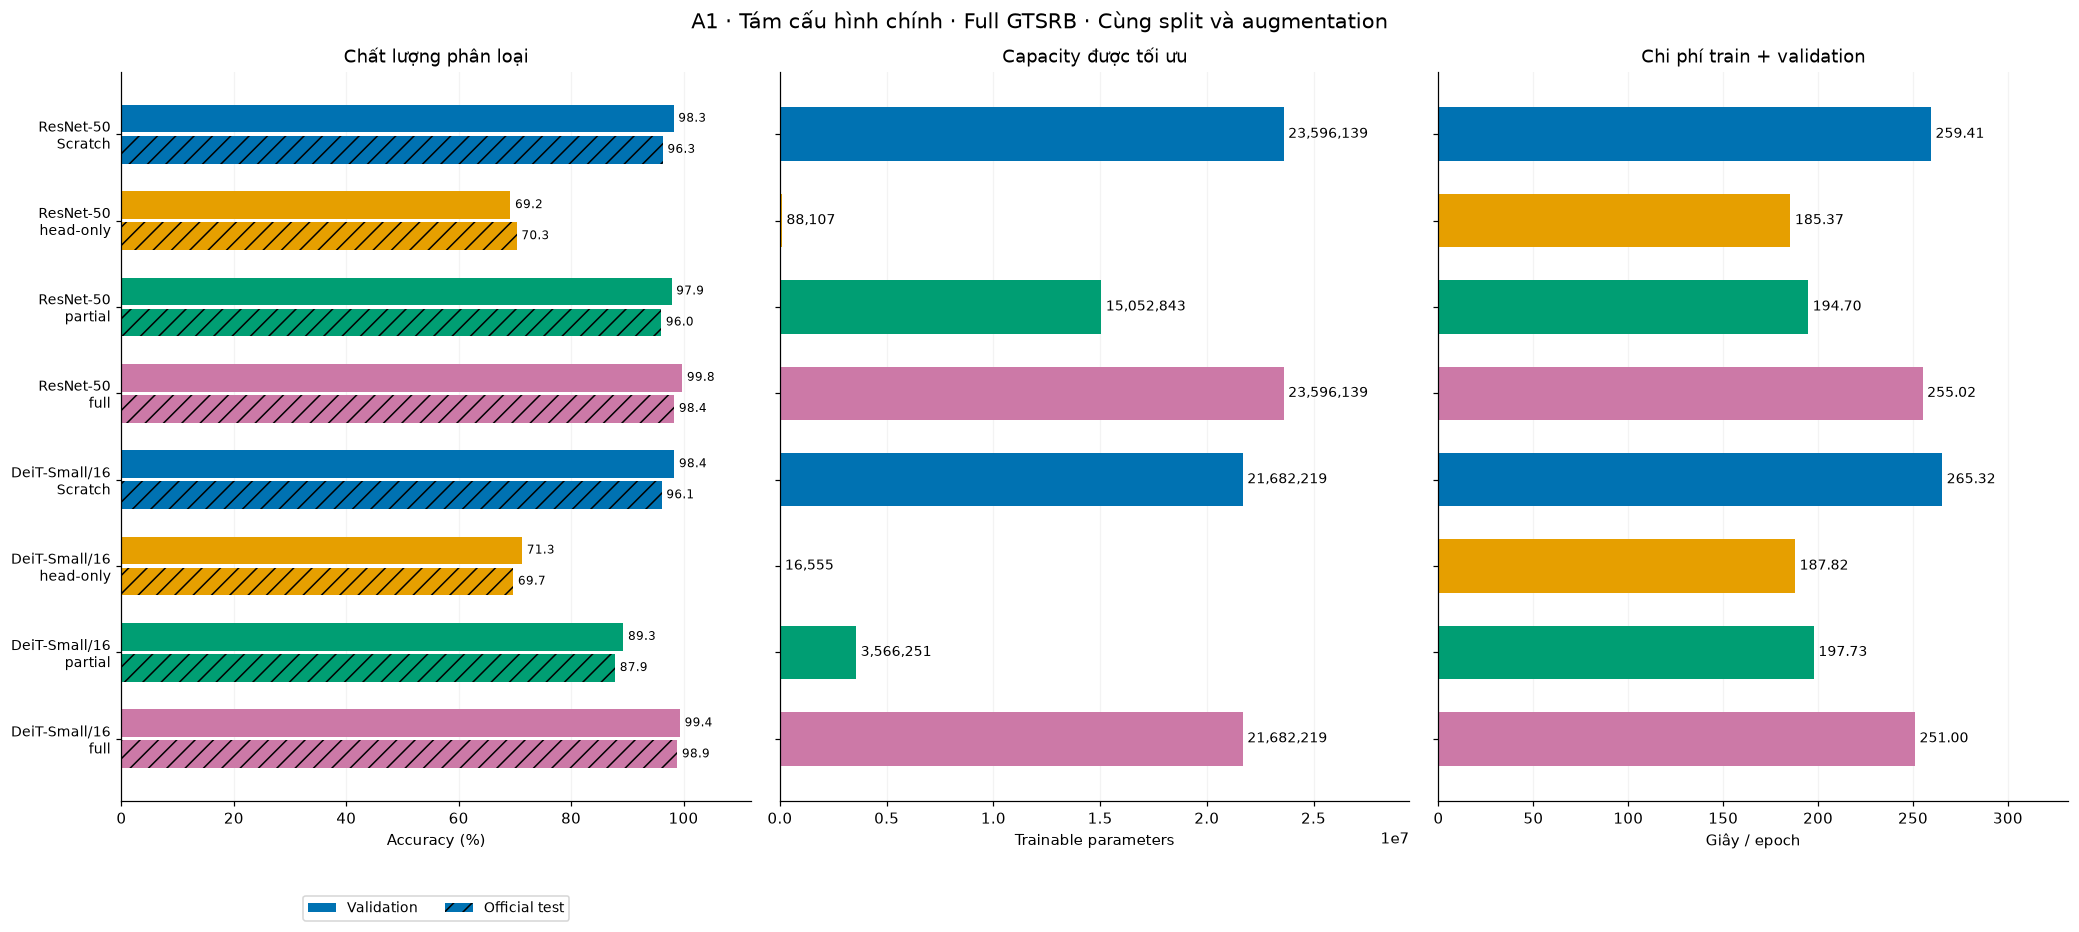

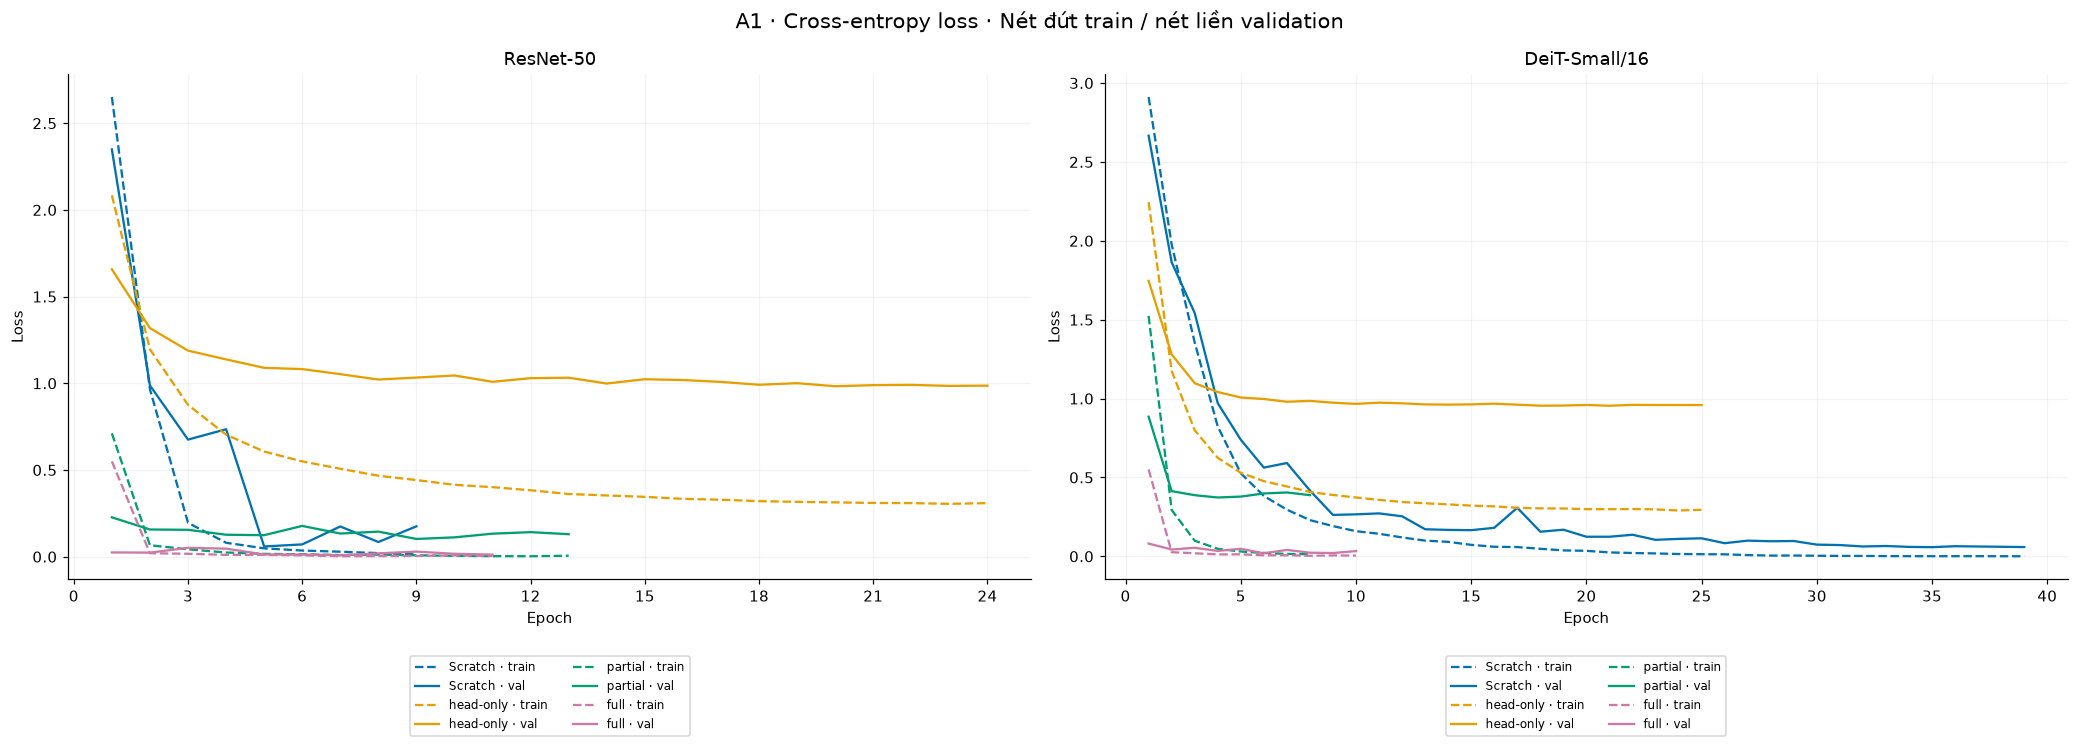

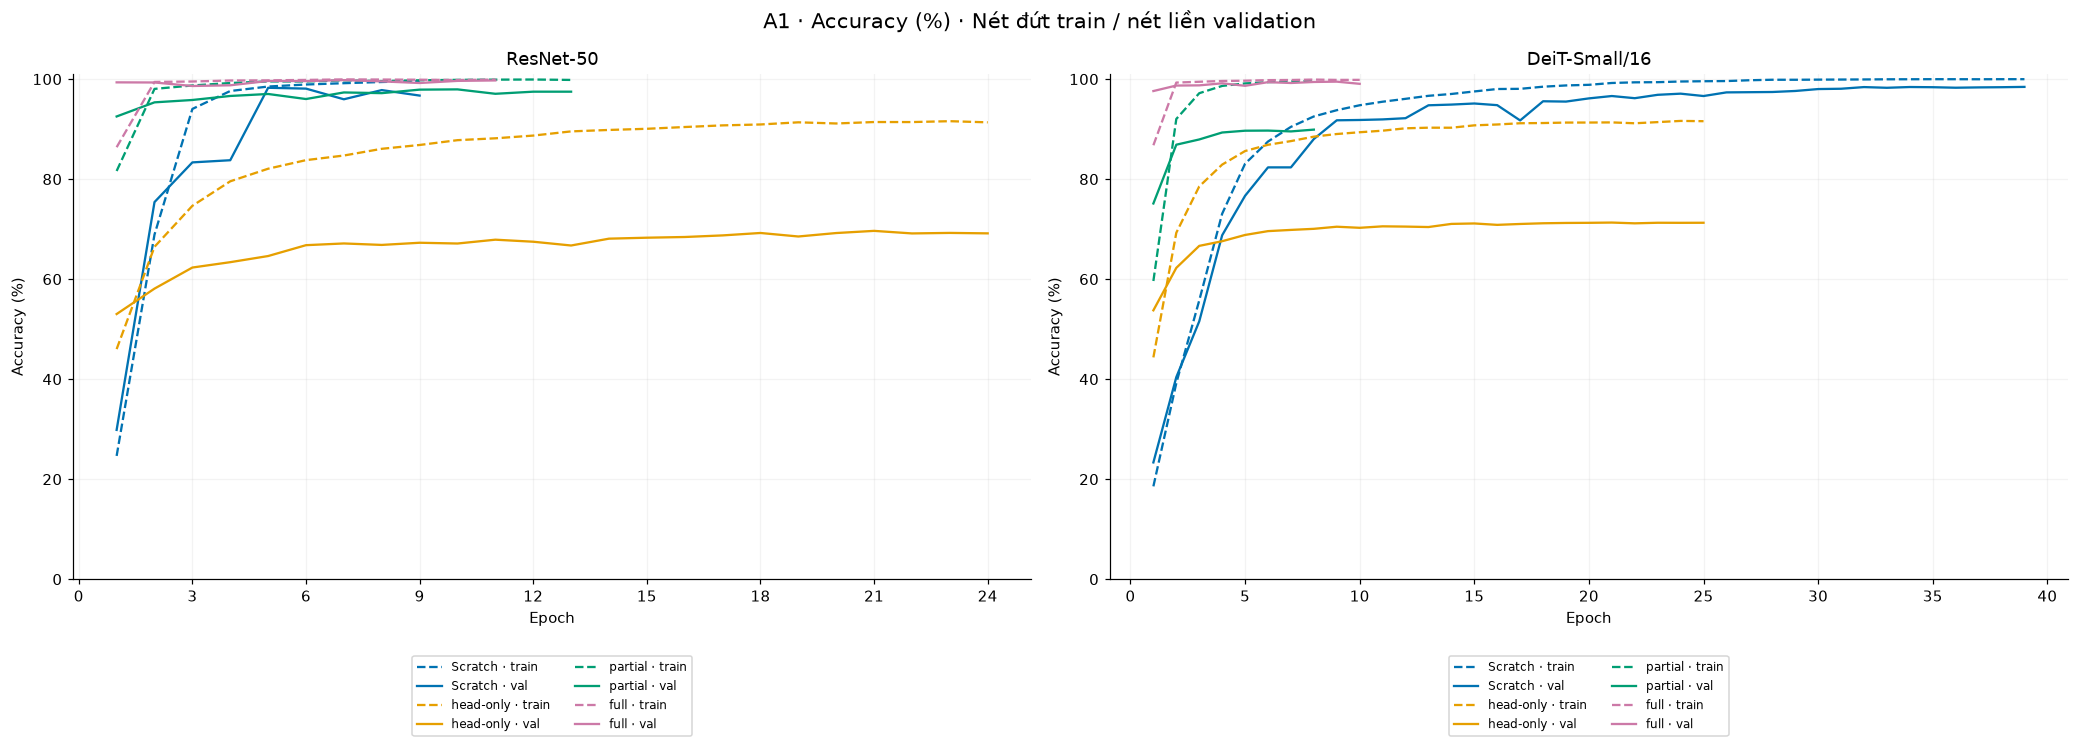

**CNN vs Transformer, cùng chế độ**

| Cùng chế độ | CNN val (%) | ViT val (%) | ViT − CNN (điểm %) | CNN test (%) | ViT test (%) | CNN / ViT s/epoch | CNN / ViT peak MiB |
|---|---:|---:|---:|---:|---:|---|---|
| Scratch | 98.26 | 98.38 | +0.11 | 96.33 | 96.14 | 259.408 / 265.317 | 5830 / 6635 |
| Pretrained · head-only | 69.22 | 71.31 | +2.09 | 70.35 | 69.73 | 185.367 / 187.817 | 1567 / 636 |
| Pretrained · partial | 97.89 | 89.32 | -8.57 | 96.05 | 87.85 | 194.699 / 197.725 | 1681 / 1374 |
| Pretrained · full | 99.80 | 99.39 | -0.41 | 98.37 | 98.92 | 255.018 / 251.002 | 5823 / 6632 |

**Scratch/pretrained và ba mức freeze**

| Họ | Pretrained full − scratch val (điểm %) | Full − head val (điểm %) | Partial − head val (điểm %) | Head / partial / full trainable |
|---|---:|---:|---:|---|
| ResNet-50 | +1.53 | +30.58 | +28.68 | 88,107 / 15,052,843 / 23,596,139 |
| DeiT-Small/16 | +1.01 | +28.08 | +18.01 | 16,555 / 3,566,251 / 21,682,219 |

**Inference FP32 · CUDA Events, tách khỏi DataLoader**

| Model | Batch inference | GPU ms/batch | GPU images/s | Test end to end (s) |
|---|---:|---:|---:|---:|
| ResNet-50 · Scratch · seed42 | 32 | 77.06 | 415.3 | 51.30 |
| ResNet-50 · Pretrained · head-only · seed42 | 32 | 77.54 | 412.7 | 45.32 |
| ResNet-50 · Pretrained · partial · seed42 | 32 | 76.63 | 417.6 | 44.35 |
| ResNet-50 · Pretrained · full · seed42 | 32 | 77.09 | 415.1 | 44.70 |
| DeiT-Small/16 · Scratch · seed42 | 32 | 138.44 | 231.1 | 64.70 |
| DeiT-Small/16 · Pretrained · head-only · seed42 | 32 | 139.91 | 228.7 | 64.56 |
| DeiT-Small/16 · Pretrained · partial · seed42 | 32 | 139.99 | 228.6 | 65.06 |
| DeiT-Small/16 · Pretrained · full · seed42 | 32 | 139.22 | 229.9 | 64.99 |

**Độ nhạy với ảnh trùng SHA256 · full test và test không trùng**

| Model | Full test acc (%) | Không trùng acc (%) | Δkhông trùng − full (điểm %) | Full F1 | Không trùng F1 | Số ảnh không trùng |
|---|---:|---:|---:|---:|---:|---:|
| ResNet-50 · Scratch · seed42 | 96.33 | 96.33 | -0.002 | 0.9447 | 0.9447 | 12,622 |
| ResNet-50 · Pretrained · head-only · seed42 | 70.35 | 70.33 | -0.019 | 0.6143 | 0.6143 | 12,622 |
| ResNet-50 · Pretrained · partial · seed42 | 96.05 | 96.05 | -0.003 | 0.9438 | 0.9438 | 12,622 |
| ResNet-50 · Pretrained · full · seed42 | 98.37 | 98.37 | -0.001 | 0.9743 | 0.9743 | 12,622 |
| DeiT-Small/16 · Scratch · seed42 | 96.14 | 96.13 | -0.002 | 0.9350 | 0.9350 | 12,622 |
| DeiT-Small/16 · Pretrained · head-only · seed42 | 69.73 | 69.71 | -0.019 | 0.6125 | 0.6125 | 12,622 |
| DeiT-Small/16 · Pretrained · partial · seed42 | 87.85 | 87.85 | -0.008 | 0.8063 | 0.8063 | 12,622 |
| DeiT-Small/16 · Pretrained · full · seed42 | 98.92 | 98.91 | -0.001 | 0.9790 | 0.9790 | 12,622 |

In [13]:
result_tables(main_results, "Tám cấu hình chính")
main_comparison(main_results)
learning_curves(main_results)
direct_comparisons(main_results)
overlap_sensitivity_report(main_results)

## 11. Số liệu augmentation và seed
Các bảng đối chiếu có/không augmentation và thống kê ba seed42/43/44.


**Sáu thực nghiệm bổ sung · Huấn luyện thực tế**

| Model | Batch × accumulation | Eval batch | Epoch | Best epoch | Updates | AMP skips | Dừng | Peak GPU (MiB) |
|---|---|---:|---:|---:|---:|---:|---|---:|
| ResNet-50 · Pretrained · full · seed42 · no augmentation | 128 × 1 | 128 | 5 | 3 | 1,230 | 0 | Early stopping | 5831 |
| ResNet-50 · Pretrained · full · seed43 | 128 × 1 | 128 | 8 | 4 | 1,968 | 0 | Early stopping | 5826 |
| ResNet-50 · Pretrained · full · seed44 | 128 × 1 | 128 | 7 | 3 | 1,722 | 0 | Early stopping | 5827 |
| DeiT-Small/16 · Pretrained · full · seed42 · no augmentation | 128 × 1 | 128 | 17 | 13 | 4,182 | 0 | Early stopping | 6633 |
| DeiT-Small/16 · Pretrained · full · seed43 | 128 × 1 | 128 | 22 | 18 | 5,412 | 0 | Early stopping | 6632 |
| DeiT-Small/16 · Pretrained · full · seed44 | 128 × 1 | 128 | 10 | 6 | 2,460 | 0 | Early stopping | 6632 |

| Model | Train acc tại best (%) | Val acc (%) | Val F1 | Test acc (%) | Test F1 | Total params | Trainable | Trainable (%) | Train + val (s) | s/epoch |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| ResNet-50 · Pretrained · full · seed42 · no augmentation | 99.57 | 98.85 | 0.9811 | 97.20 | 0.9545 | 23,596,139 | 23,596,139 | 100.00 | 941.91 | 188.382 |
| ResNet-50 · Pretrained · full · seed43 | 99.79 | 99.92 | 0.9991 | 98.76 | 0.9834 | 23,596,139 | 23,596,139 | 100.00 | 1912.95 | 239.119 |
| ResNet-50 · Pretrained · full · seed44 | 99.54 | 99.28 | 0.9881 | 98.19 | 0.9630 | 23,596,139 | 23,596,139 | 100.00 | 1717.14 | 245.305 |
| DeiT-Small/16 · Pretrained · full · seed42 · no augmentation | 99.99 | 99.46 | 0.9896 | 99.22 | 0.9896 | 21,682,219 | 21,682,219 | 100.00 | 3547.77 | 208.692 |
| DeiT-Small/16 · Pretrained · full · seed43 | 100.00 | 99.85 | 0.9963 | 99.29 | 0.9914 | 21,682,219 | 21,682,219 | 100.00 | 6838.98 | 310.863 |
| DeiT-Small/16 · Pretrained · full · seed44 | 99.74 | 99.50 | 0.9908 | 98.64 | 0.9781 | 21,682,219 | 21,682,219 | 100.00 | 2510.36 | 251.036 |

**Ablation augmentation · Seed42, cùng cấu hình**

| Họ / cấu hình cố định | Aug val (%) | No-aug val (%) | Aug − no-aug (điểm %) | Aug / no-aug test (%) |
|---|---:|---:|---:|---|
| ResNet-50 / Pretrained · full | 99.80 | 98.85 | +0.95 | 98.37 / 97.20 |
| DeiT-Small/16 / Pretrained · full | 99.39 | 99.46 | -0.08 | 98.92 / 99.22 |

**Lặp ba seed · Std mẫu (ddof=1), cùng split seed42**

| Họ / cấu hình | Seeds | Val acc mean±std (%) | Test acc mean±std (%) | Val macro-F1 mean±std | Test macro-F1 mean±std |
|---|---|---|---|---|---|
| ResNet-50 / Pretrained · full | 42/43/44 | 99.67±0.34 | 98.44±0.29 | 0.9951±0.0061 | 0.9736±0.0102 |
| DeiT-Small/16 / Pretrained · full | 42/43/44 | 99.58±0.24 | 98.95±0.33 | 0.9912±0.0050 | 0.9828±0.0074 |

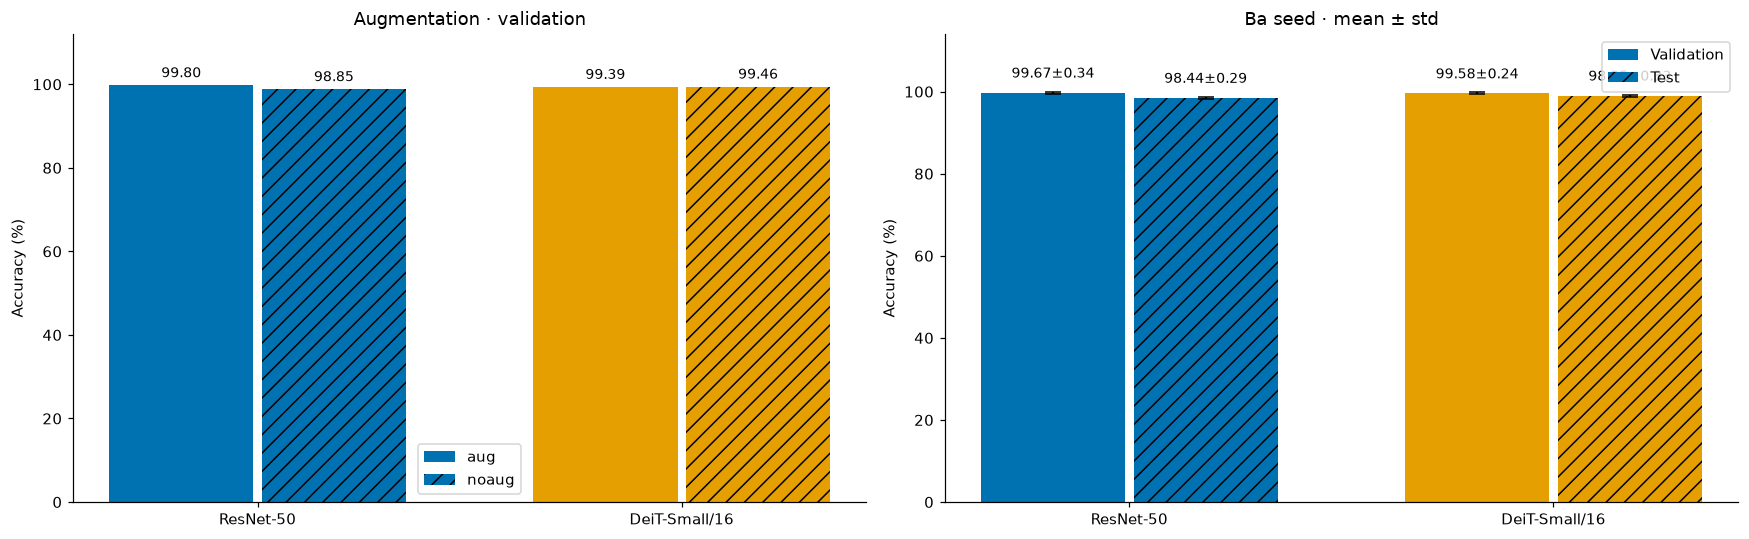

In [14]:
result_tables(results[8:], "Sáu thực nghiệm bổ sung")
seed_summaries = augmentation_and_seed_report()

## 12. Confusion matrix và mẫu dự đoán sai
Mỗi ô ghi số ảnh và tỷ lệ theo lớp thật. Class ID đối chiếu với bảng nhãn.


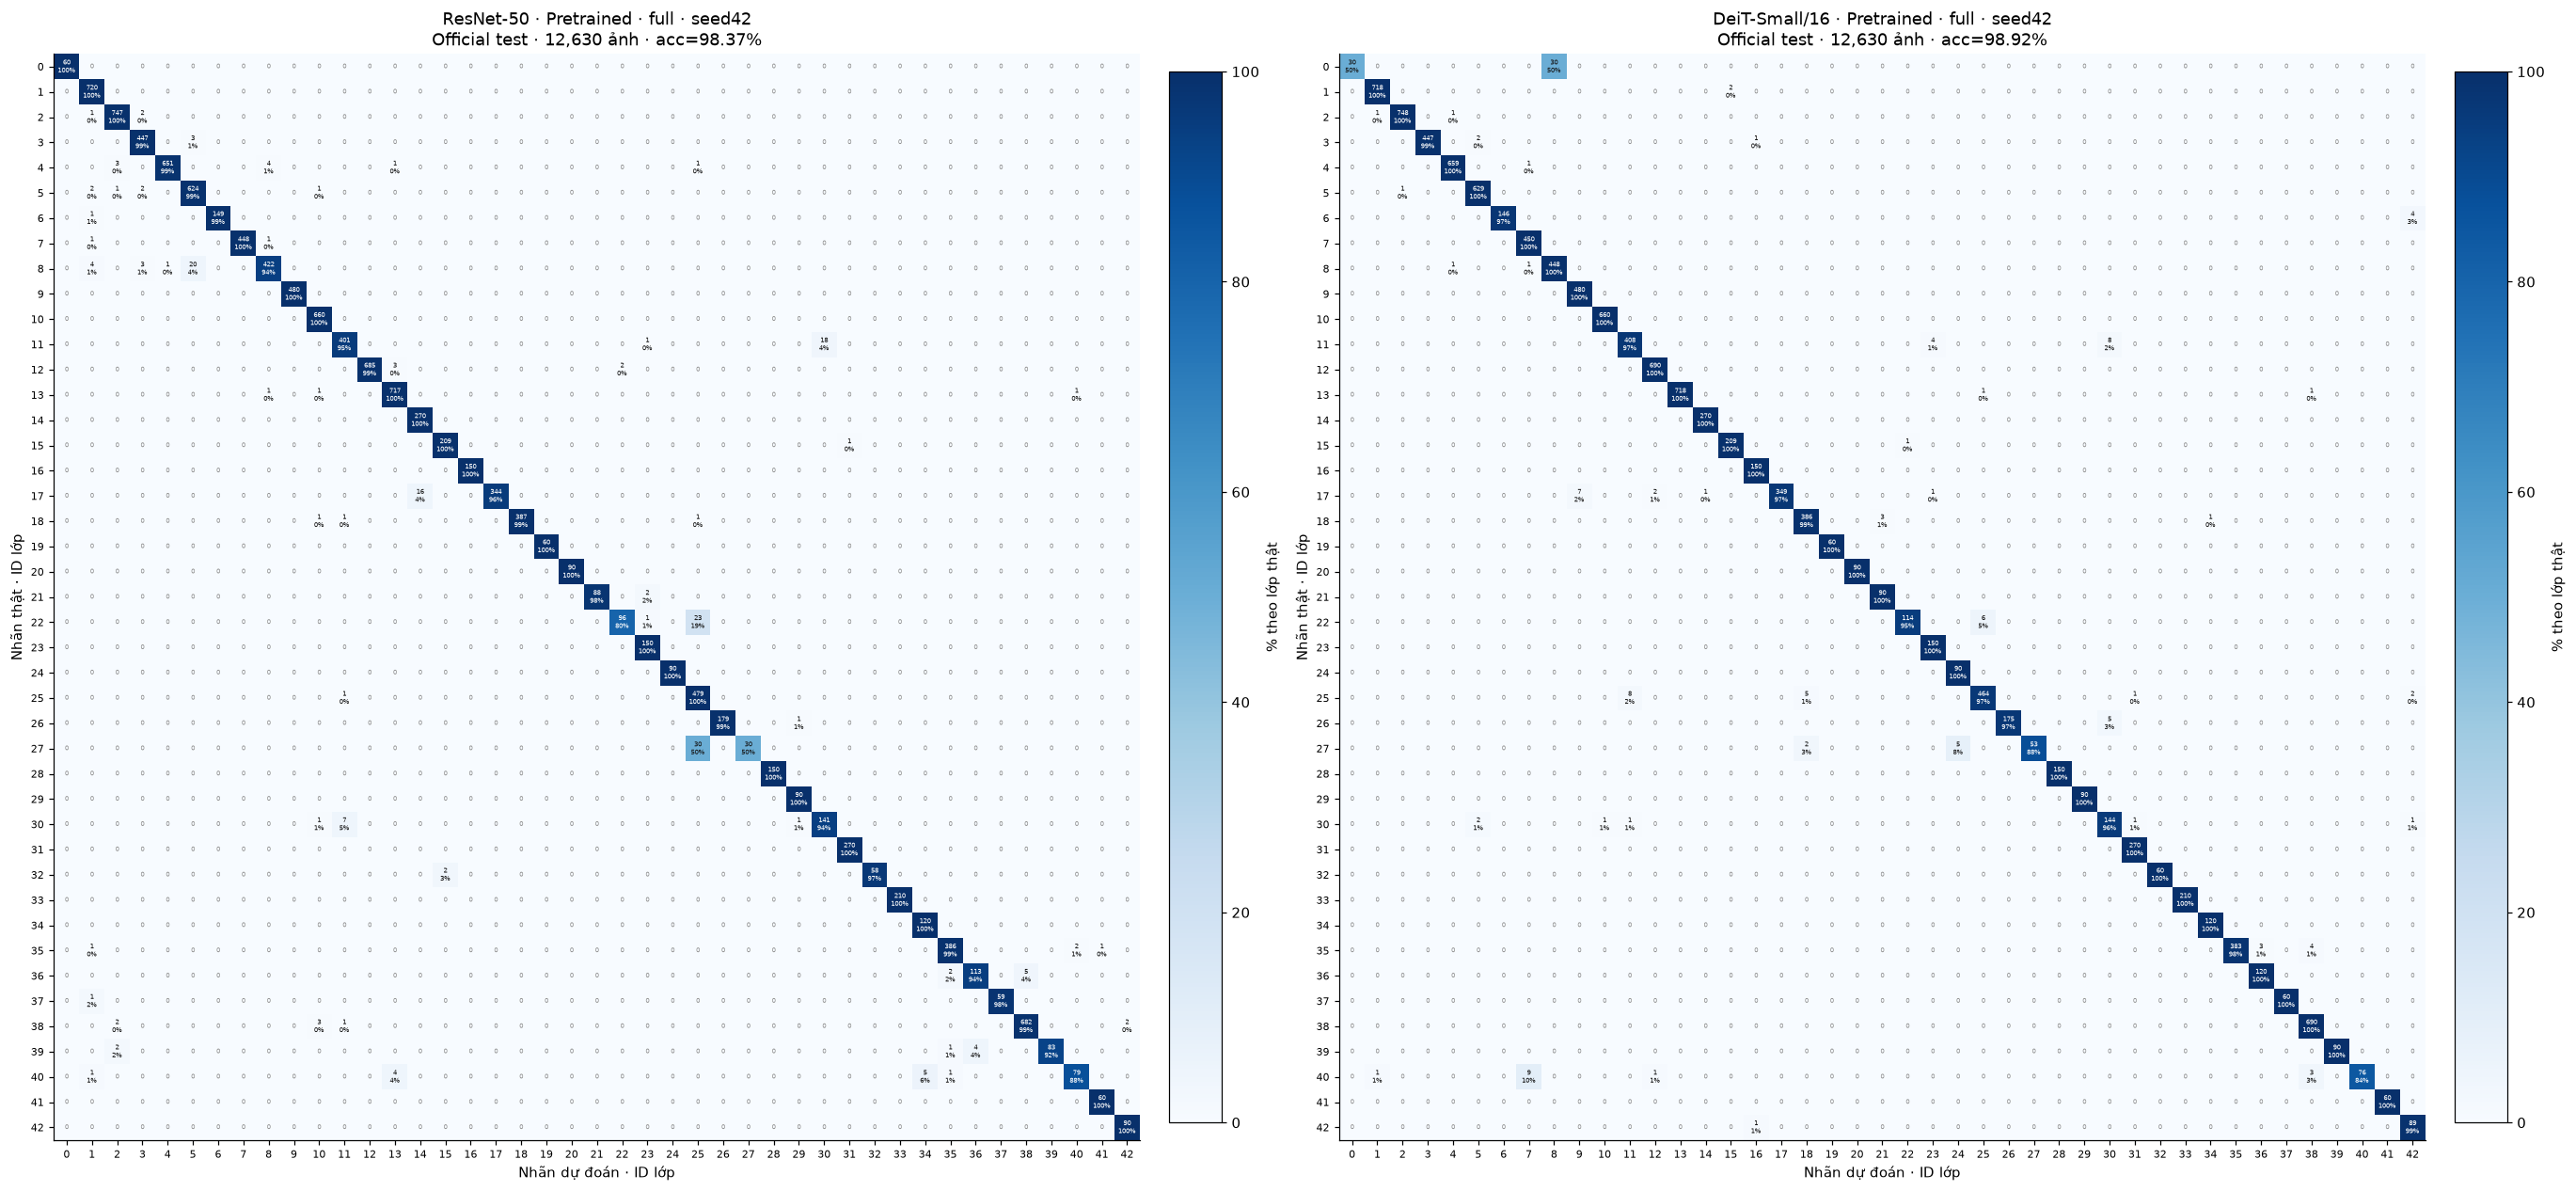

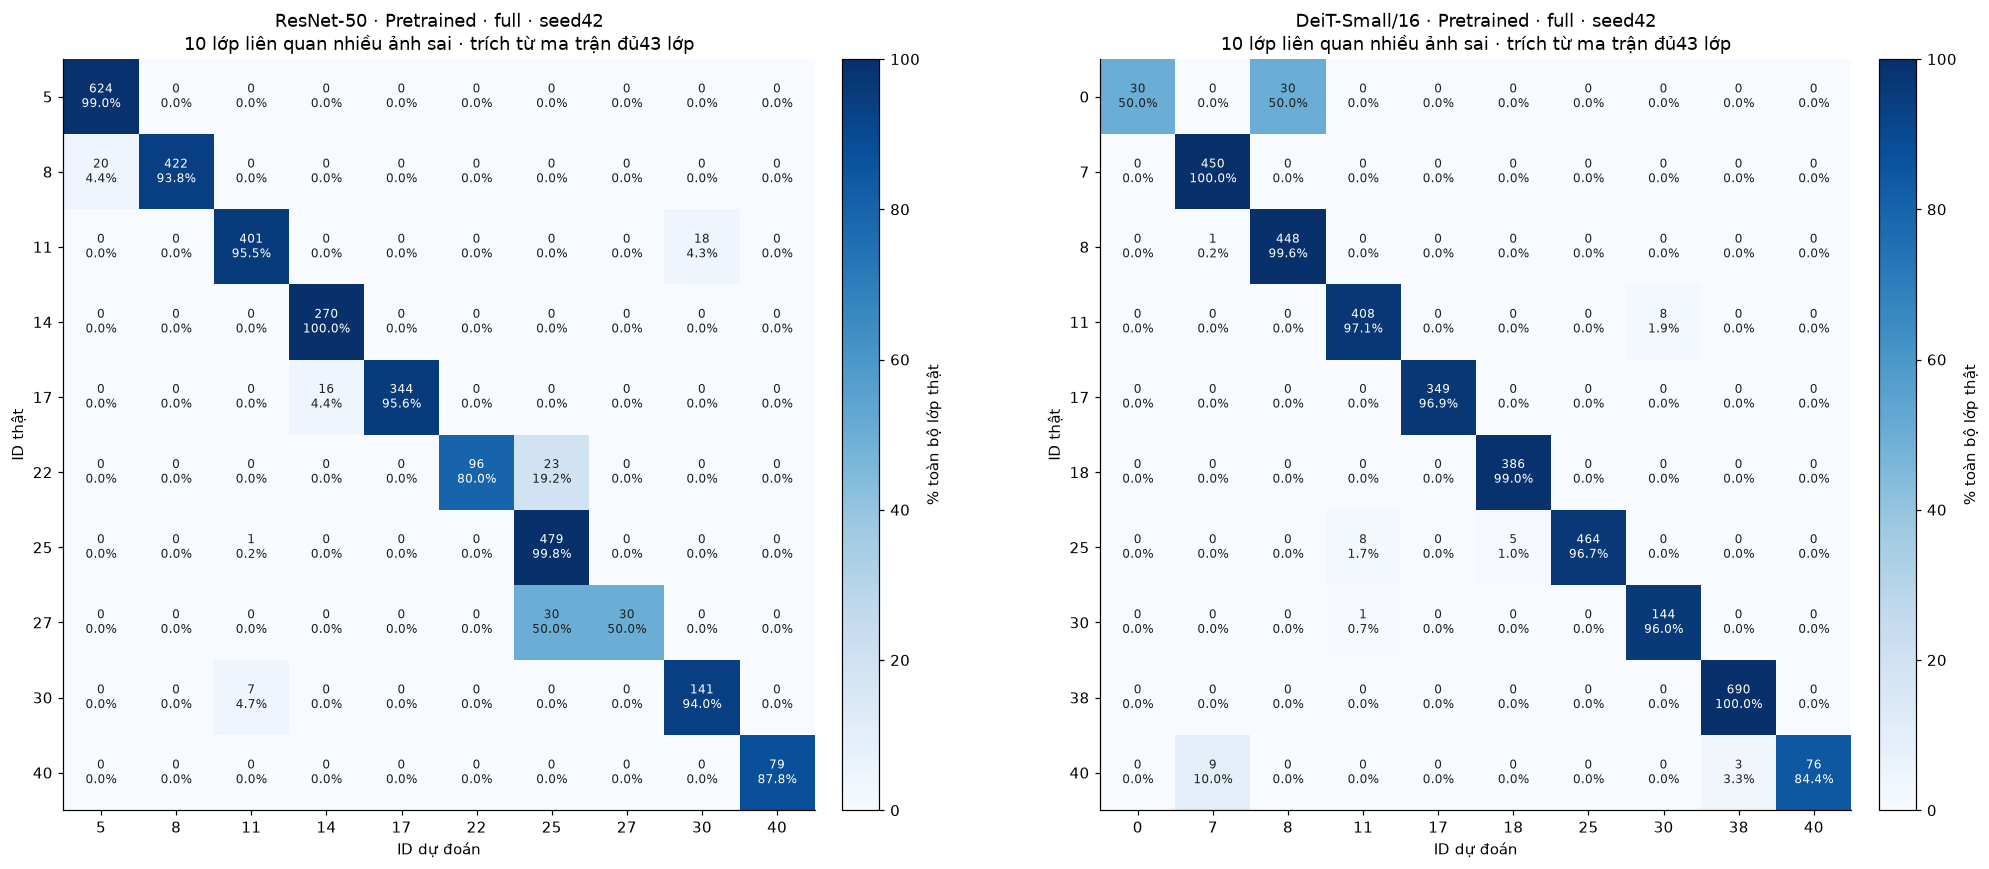

**Cặp nhầm lẫn nhiều nhất · 8 cấu hình chính**

| Model | Lớp thật → dự đoán nhầm nhiều nhất | Số ảnh | % lớp thật |
|---|---|---:|---:|
| ResNet-50 · Scratch · seed42 | 27: Pedestrians → 11: Right-of-way intersection | 29 | 48.33% |
| ResNet-50 · Pretrained · head-only · seed42 | 1: Speed limit 30 → 2: Speed limit 50 | 201 | 27.92% |
| ResNet-50 · Pretrained · partial · seed42 | 5: Speed limit 80 → 2: Speed limit 50 | 49 | 7.78% |
| ResNet-50 · Pretrained · full · seed42 | 27: Pedestrians → 25: Road work | 30 | 50.00% |
| DeiT-Small/16 · Scratch · seed42 | 27: Pedestrians → 25: Road work | 26 | 43.33% |
| DeiT-Small/16 · Pretrained · head-only · seed42 | 1: Speed limit 30 → 2: Speed limit 50 | 135 | 18.75% |
| DeiT-Small/16 · Pretrained · partial · seed42 | 34: Turn left ahead → 33: Turn right ahead | 78 | 65.00% |
| DeiT-Small/16 · Pretrained · full · seed42 | 0: Speed limit 20 → 8: Speed limit 120 | 30 | 50.00% |

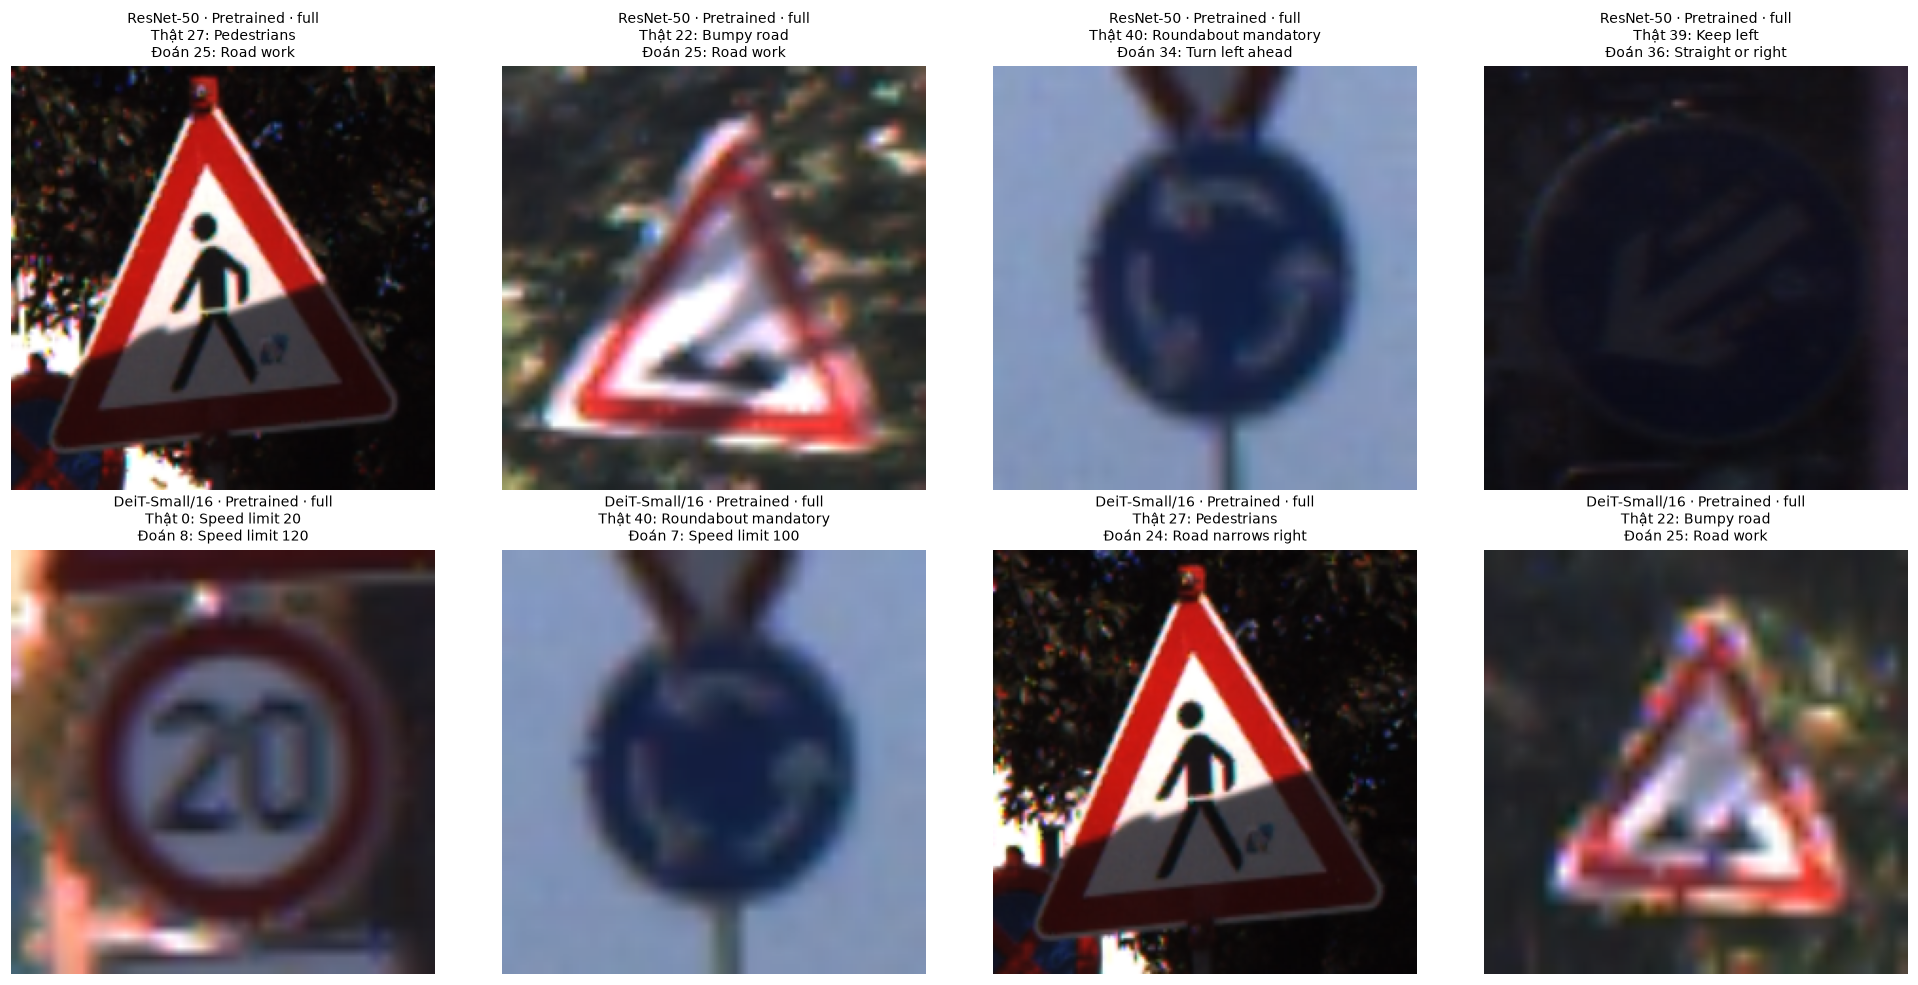

**Per-class metrics · hai cấu hình chọn bằng validation**

| ID / ý nghĩa | Test support | CNN Precision / Recall / F1 | Transformer Precision / Recall / F1 |
|---|---:|---|---|
| 0: Speed limit 20 | 60 | 1.000 / 1.000 / 1.000 | 1.000 / 0.500 / 0.667 |
| 1: Speed limit 30 | 720 | 0.984 / 1.000 / 0.992 | 0.997 / 0.997 / 0.997 |
| 2: Speed limit 50 | 750 | 0.989 / 0.996 / 0.993 | 0.999 / 0.997 / 0.998 |
| 3: Speed limit 60 | 450 | 0.985 / 0.993 / 0.989 | 1.000 / 0.993 / 0.997 |
| 4: Speed limit 70 | 660 | 0.998 / 0.986 / 0.992 | 0.997 / 0.998 / 0.998 |
| 5: Speed limit 80 | 630 | 0.964 / 0.990 / 0.977 | 0.994 / 0.998 / 0.996 |
| 6: End speed limit 80 | 150 | 1.000 / 0.993 / 0.997 | 1.000 / 0.973 / 0.986 |
| 7: Speed limit 100 | 450 | 1.000 / 0.996 / 0.998 | 0.976 / 1.000 / 0.988 |
| 8: Speed limit 120 | 450 | 0.986 / 0.938 / 0.961 | 0.937 / 0.996 / 0.966 |
| 9: No passing | 480 | 1.000 / 1.000 / 1.000 | 0.986 / 1.000 / 0.993 |
| 10: No passing >3.5t | 660 | 0.990 / 1.000 / 0.995 | 0.998 / 1.000 / 0.999 |
| 11: Right-of-way intersection | 420 | 0.976 / 0.955 / 0.965 | 0.978 / 0.971 / 0.975 |
| 12: Priority road | 690 | 1.000 / 0.993 / 0.996 | 0.996 / 1.000 / 0.998 |
| 13: Yield | 720 | 0.989 / 0.996 / 0.992 | 1.000 / 0.997 / 0.999 |
| 14: Stop | 270 | 0.944 / 1.000 / 0.971 | 0.996 / 1.000 / 0.998 |
| 15: No vehicles | 210 | 0.991 / 0.995 / 0.993 | 0.991 / 0.995 / 0.993 |
| 16: Vehicles >3.5t prohibited | 150 | 1.000 / 1.000 / 1.000 | 0.987 / 1.000 / 0.993 |
| 17: No entry | 360 | 1.000 / 0.956 / 0.977 | 1.000 / 0.969 / 0.984 |
| 18: General caution | 390 | 1.000 / 0.992 / 0.996 | 0.982 / 0.990 / 0.986 |
| 19: Dangerous curve left | 60 | 1.000 / 1.000 / 1.000 | 1.000 / 1.000 / 1.000 |
| 20: Dangerous curve right | 90 | 1.000 / 1.000 / 1.000 | 1.000 / 1.000 / 1.000 |
| 21: Double curve | 90 | 1.000 / 0.978 / 0.989 | 0.968 / 1.000 / 0.984 |
| 22: Bumpy road | 120 | 0.980 / 0.800 / 0.881 | 0.991 / 0.950 / 0.970 |
| 23: Slippery road | 150 | 0.974 / 1.000 / 0.987 | 0.968 / 1.000 / 0.984 |
| 24: Road narrows right | 90 | 1.000 / 1.000 / 1.000 | 0.947 / 1.000 / 0.973 |
| 25: Road work | 480 | 0.897 / 0.998 / 0.945 | 0.985 / 0.967 / 0.976 |
| 26: Traffic signals | 180 | 1.000 / 0.994 / 0.997 | 1.000 / 0.972 / 0.986 |
| 27: Pedestrians | 60 | 1.000 / 0.500 / 0.667 | 1.000 / 0.883 / 0.938 |
| 28: Children crossing | 150 | 1.000 / 1.000 / 1.000 | 1.000 / 1.000 / 1.000 |
| 29: Bicycle crossing | 90 | 0.978 / 1.000 / 0.989 | 1.000 / 1.000 / 1.000 |
| 30: Ice/snow caution | 150 | 0.887 / 0.940 / 0.913 | 0.917 / 0.960 / 0.938 |
| 31: Wild animals crossing | 270 | 0.996 / 1.000 / 0.998 | 0.993 / 1.000 / 0.996 |
| 32: End speed/passing limits | 60 | 1.000 / 0.967 / 0.983 | 1.000 / 1.000 / 1.000 |
| 33: Turn right ahead | 210 | 1.000 / 1.000 / 1.000 | 1.000 / 1.000 / 1.000 |
| 34: Turn left ahead | 120 | 0.960 / 1.000 / 0.980 | 0.992 / 1.000 / 0.996 |
| 35: Ahead only | 390 | 0.990 / 0.990 / 0.990 | 1.000 / 0.982 / 0.991 |
| 36: Straight or right | 120 | 0.966 / 0.942 / 0.954 | 0.976 / 1.000 / 0.988 |
| 37: Straight or left | 60 | 1.000 / 0.983 / 0.992 | 1.000 / 1.000 / 1.000 |
| 38: Keep right | 690 | 0.993 / 0.988 / 0.991 | 0.989 / 1.000 / 0.994 |
| 39: Keep left | 90 | 1.000 / 0.922 / 0.960 | 1.000 / 1.000 / 1.000 |
| 40: Roundabout mandatory | 90 | 0.963 / 0.878 / 0.919 | 1.000 / 0.844 / 0.916 |
| 41: End no passing | 60 | 0.984 / 1.000 / 0.992 | 1.000 / 1.000 / 1.000 |
| 42: End no passing >3.5t | 90 | 0.978 / 1.000 / 0.989 | 0.927 / 0.989 / 0.957 |

In [15]:
error_report(main_results, selected)

## 13. Kiểm tra số liệu và split
Kiểm tra số model, số ảnh, checkpoint và tính nhất quán của metric trong lần chạy.


In [16]:
assert len(results) == 14 and len(RUN_CONFIGS) == len(CHECKPOINTS) == 14
for r in results:
    run = r["run"]
    history = histories[run]
    assert r["micro_batch"] == BATCH_SIZE and r["accumulation"] == ACCUMULATION_STEPS
    assert r["evaluation_batch"] == BATCH_SIZE
    assert r["best_epoch"] == min(history, key=lambda row: row["val_loss"])["epoch"]
    assert r["optimizer_updates"] + r["amp_skips"] == len(history) * math.ceil(
        31_380 / EFFECTIVE_BATCH
    )
    assert all(row["train_samples"] == 31_380 for row in history)
    assert np.isfinite(
        [
            r[key]
            for key in [
                "val_loss",
                "val_accuracy",
                "val_macro_f1",
                "test_loss",
                "test_accuracy",
                "test_macro_f1",
            ]
        ]
    ).all()
    for split, expected in [("validation", 7_829), ("test", 12_630)]:
        metric = evaluations[run][split]
        assert (
            metric["cm"].shape == (43, 43)
            and metric["samples"] == int(metric["cm"].sum()) == expected
        )
        assert np.array_equal(metric["cm"].sum(axis=1), SPLIT_COUNTS[split])
        assert np.isclose(metric["accuracy"], np.trace(metric["cm"]) / expected)
        assert np.isclose(metric["macro_f1"], class_metrics(metric["cm"])[2].mean())
for r in results:
    unique = evaluations[r["run"]]["test"]["unique_test"]
    assert unique["samples"] == 12_630 - OVERLAP_TEST_IMAGES == r["unique_test_samples"]
    assert np.isclose(unique["accuracy"], np.trace(unique["cm"]) / unique["samples"])
log(
    "AUDIT",
    f"PASS · 14 model · {sum(r['epochs'] for r in results)} epoch · "
    f"{sum(r['optimizer_updates'] for r in results):,} CUDA optimizer updates · toàn bộ train/val/test.",
)
finish_notebook()

[00:39:05] [AUDIT] PASS · 14 model · 208 epoch · 51,168 CUDA optimizer updates · toàn bộ train/val/test.
[00:39:05] [THÍ NGHIỆM] Hoàn tất đánh giá 14 model trên toàn bộ test.


### Hướng dẫn sử dụng và nguồn
Chọn Python3.14 có PyTorch CUDA và thư viện đã liệt kê ở cell môi trường;
Restart Kernel → Run All. Dữ liệu nằm tại `datasets/gtsrb`, metadata/samples.csv
phải đúng manifest đã công bố. Checkpoint pretrained được lấy từ cache
`datasets/pretrained/checkpoints`; nếu cache thiếu, torchvision/torch.hub tải nguồn
chính thức. Không giới hạn ảnh, batch hay epoch bằng chế độ thử trong cấu hình bàn giao.

Lưu notebook sau khi chạy để giữ bảng/hình/text progress trong output cell.
Những số liệu/weights giữ RAM không tự ghi file. Mỗi notebook chứa trọn logic riêng
và chỉ dùng dữ liệu/cache dùng chung; không import hay gọi notebook khác.

- [Đề Assignment1](../assignment/assignment1-vne.pdf), [Dataset README](../datasets/README.md).
- [GTSRB benchmark](https://benchmark.ini.rub.de/gtsrb_news.html),
  [archive chính thức ERDA](https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/published-archive.html).
- [torchvision ResNet-50 weights](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet50.html).
- [DeiT implementation và checkpoint non-distilled](https://github.com/facebookresearch/deit),
  [DeiT paper](https://arxiv.org/abs/2012.12877).